In [1]:
# %reset
import numpy as np
import sys,os
import readgadget
import MAS_library as MASL
import pickle as pk
import readfof
import matplotlib

import matplotlib.pyplot as pl
pl.rc('text', usetex=True)
# Palatino
pl.rc('font', family='DejaVu Sans')
%matplotlib inline



%load_ext Cython

    




In [2]:
%%cython
cimport numpy as np
cpdef void NGP_xyz_vel(np.float32_t[:,:] pos, np.float32_t[:,:] vel, np.float32_t[:,:,:,:,:] gridM, float BoxSize):

    cdef int axis,dims,coord,nMmax,jM
    cdef long i,particles
    cdef float inv_cell_size
    cdef float pos0, pos1, pos2
    cdef int index[3]
    cdef int tobreak

    # find number of particles, the inverse of the cell size and dims
    particles = pos.shape[0];  coord = pos.shape[1];  dims = gridM.shape[0]; nMmax = gridM.shape[3]
    inv_cell_size = dims/BoxSize

    # when computing things in 2D, use the index[2]=0 plane
    for i in range(3):  index[i] = 0

    # do a loop over all particles
    for i in range(particles):
        for axis in range(coord):
            index[axis] = <int>(pos[i,axis]*inv_cell_size + 0.5)
            if axis == 0:
                pos0 = pos[i,axis] - index[axis]*BoxSize/dims
            if axis == 1:
                pos1 = pos[i,axis] - index[axis]*BoxSize/dims
            if axis == 2:
                pos2 = pos[i,axis] - index[axis]*BoxSize/dims
            index[axis] = (index[axis]+dims)%dims
        for jM in range(nMmax):
            if (gridM[index[0],index[1],index[2], jM, 0] == 0) and (gridM[index[0],index[1],index[2], jM, 1] == 0) and (gridM[index[0],index[1],index[2], jM, 2] == 0) and (gridM[index[0],index[1],index[2], jM, 3] == 0):
                gridM[index[0],index[1],index[2], jM, 0] = pos0
                gridM[index[0],index[1],index[2], jM, 1] = pos1
                gridM[index[0],index[1],index[2], jM, 2] = pos2

                gridM[index[0],index[1],index[2], jM, 3] = vel[i,0]
                gridM[index[0],index[1],index[2], jM, 4] = vel[i,1]
                gridM[index[0],index[1],index[2], jM, 5] = vel[i,2]                                

                # gridM[index[0],index[1],index[2], jM, 6] = logM[i]
                
                break
            else:
                pass
                    
        
        

In file included from /mnt/home/spandey/miniconda3/envs/ili-sbi/lib/python3.10/site-packages/numpy/core/include/numpy/ndarraytypes.h:1929,
                 from /mnt/home/spandey/miniconda3/envs/ili-sbi/lib/python3.10/site-packages/numpy/core/include/numpy/ndarrayobject.h:12,
                 from /mnt/home/spandey/miniconda3/envs/ili-sbi/lib/python3.10/site-packages/numpy/core/include/numpy/arrayobject.h:5,
                 from /dev/shm/.cache-spandey/ipython/cython/_cython_magic_4feafffeeb2dda14554f98ceafcbd473.c:775:
/mnt/home/spandey/miniconda3/envs/ili-sbi/lib/python3.10/site-packages/numpy/core/include/numpy/npy_1_7_deprecated_api.h:17:2: warning: #warning "Using deprecated NumPy API, disable it with " "#define NPY_NO_DEPRECATED_API NPY_1_7_API_VERSION" [-Wcpp]
   17 | #warning "Using deprecated NumPy API, disable it with " \
      |  ^~~~~~~
/dev/shm/.cache-spandey/ipython/cython/_cython_magic_4feafffeeb2dda14554f98ceafcbd473.c: In function '__pyx_pw_46_cython_magic_4feafffeeb2

In [3]:
%%cython
cimport numpy as np
cpdef void NGP_xyz(np.float32_t[:,:] pos, np.float32_t[:,:,:,:,:] gridM, float BoxSize):

    cdef int axis,dims,coord,nMmax,jM
    cdef long i,particles
    cdef float inv_cell_size
    cdef float pos0, pos1, pos2
    cdef int index[3]
    cdef int tobreak

    # find number of particles, the inverse of the cell size and dims
    particles = pos.shape[0];  coord = pos.shape[1];  dims = gridM.shape[0]; nMmax = gridM.shape[3]
    inv_cell_size = dims/BoxSize

    # when computing things in 2D, use the index[2]=0 plane
    for i in range(3):  index[i] = 0

    # do a loop over all particles
    for i in range(particles):
        for axis in range(coord):
            index[axis] = <int>(pos[i,axis]*inv_cell_size + 0.5)
            if axis == 0:
                pos0 = pos[i,axis] - index[axis]*BoxSize/dims
            if axis == 1:
                pos1 = pos[i,axis] - index[axis]*BoxSize/dims
            if axis == 2:
                pos2 = pos[i,axis] - index[axis]*BoxSize/dims
            index[axis] = (index[axis]+dims)%dims
        for jM in range(nMmax):
            if (gridM[index[0],index[1],index[2], jM, 0] == 0) and (gridM[index[0],index[1],index[2], jM, 1] == 0) and (gridM[index[0],index[1],index[2], jM, 2] == 0):
                gridM[index[0],index[1],index[2], jM, 0] = pos0
                gridM[index[0],index[1],index[2], jM, 1] = pos1
                gridM[index[0],index[1],index[2], jM, 2] = pos2
                # gridM[index[0],index[1],index[2], jM, 3] = logM[i]
                break
            else:
                pass


            

In file included from /mnt/home/spandey/miniconda3/envs/ili-sbi/lib/python3.10/site-packages/numpy/core/include/numpy/ndarraytypes.h:1929,
                 from /mnt/home/spandey/miniconda3/envs/ili-sbi/lib/python3.10/site-packages/numpy/core/include/numpy/ndarrayobject.h:12,
                 from /mnt/home/spandey/miniconda3/envs/ili-sbi/lib/python3.10/site-packages/numpy/core/include/numpy/arrayobject.h:5,
                 from /dev/shm/.cache-spandey/ipython/cython/_cython_magic_3007918a1378e9a4e92258b6f470101a.c:776:
/mnt/home/spandey/miniconda3/envs/ili-sbi/lib/python3.10/site-packages/numpy/core/include/numpy/npy_1_7_deprecated_api.h:17:2: warning: #warning "Using deprecated NumPy API, disable it with " "#define NPY_NO_DEPRECATED_API NPY_1_7_API_VERSION" [-Wcpp]
   17 | #warning "Using deprecated NumPy API, disable it with " \
      |  ^~~~~~~
/dev/shm/.cache-spandey/ipython/cython/_cython_magic_3007918a1378e9a4e92258b6f470101a.c: In function '__pyx_pw_46_cython_magic_3007918a137

In [4]:

%%cython
cimport numpy as np
cpdef void NGP_xyzM(np.float32_t[:,:] pos, np.float32_t[:] logM, np.float32_t[:,:,:,:,:] gridM, float BoxSize):

    cdef int axis,dims,coord,nMmax,jM
    cdef long i,particles
    cdef float inv_cell_size
    cdef float pos0, pos1, pos2
    cdef int index[3]
    cdef int tobreak

    # find number of particles, the inverse of the cell size and dims
    particles = pos.shape[0];  coord = pos.shape[1];  dims = gridM.shape[0]; nMmax = gridM.shape[3]
    inv_cell_size = dims/BoxSize

    # when computing things in 2D, use the index[2]=0 plane
    for i in range(3):  index[i] = 0

    # do a loop over all particles
    for i in range(particles):
        for axis in range(coord):
            index[axis] = <int>(pos[i,axis]*inv_cell_size + 0.5)
            if axis == 0:
                pos0 = pos[i,axis] - index[axis]*BoxSize/dims
            if axis == 1:
                pos1 = pos[i,axis] - index[axis]*BoxSize/dims
            if axis == 2:
                pos2 = pos[i,axis] - index[axis]*BoxSize/dims
            index[axis] = (index[axis]+dims)%dims
        for jM in range(nMmax):
            if (gridM[index[0],index[1],index[2], jM, 0] == 0) and (gridM[index[0],index[1],index[2], jM, 1] == 0) and (gridM[index[0],index[1],index[2], jM, 2] == 0) and (gridM[index[0],index[1],index[2], jM, 3] == 0):
                gridM[index[0],index[1],index[2], jM, 0] = pos0
                gridM[index[0],index[1],index[2], jM, 1] = pos1
                gridM[index[0],index[1],index[2], jM, 2] = pos2
                gridM[index[0],index[1],index[2], jM, 3] = logM[i]
                break
            else:
                pass


            
            
            

In file included from /mnt/home/spandey/miniconda3/envs/ili-sbi/lib/python3.10/site-packages/numpy/core/include/numpy/ndarraytypes.h:1929,
                 from /mnt/home/spandey/miniconda3/envs/ili-sbi/lib/python3.10/site-packages/numpy/core/include/numpy/ndarrayobject.h:12,
                 from /mnt/home/spandey/miniconda3/envs/ili-sbi/lib/python3.10/site-packages/numpy/core/include/numpy/arrayobject.h:5,
                 from /dev/shm/.cache-spandey/ipython/cython/_cython_magic_ee7ed4c6b8443d8511f8428edf243dd6.c:777:
/mnt/home/spandey/miniconda3/envs/ili-sbi/lib/python3.10/site-packages/numpy/core/include/numpy/npy_1_7_deprecated_api.h:17:2: warning: #warning "Using deprecated NumPy API, disable it with " "#define NPY_NO_DEPRECATED_API NPY_1_7_API_VERSION" [-Wcpp]
   17 | #warning "Using deprecated NumPy API, disable it with " \
      |  ^~~~~~~
/dev/shm/.cache-spandey/ipython/cython/_cython_magic_ee7ed4c6b8443d8511f8428edf243dd6.c: In function '__pyx_pw_46_cython_magic_ee7ed4c6b84

In [5]:

%%cython
cimport numpy as np
cpdef void NGP_xyzM_vel(np.float32_t[:,:] pos, np.float32_t[:,:] vel, np.float32_t[:] logM, np.float32_t[:,:,:,:,:] gridM, float BoxSize):

    cdef int axis,dims,coord,nMmax,jM
    cdef long i,particles
    cdef float inv_cell_size
    cdef float pos0, pos1, pos2
    cdef int index[3]
    cdef int tobreak

    # find number of particles, the inverse of the cell size and dims
    particles = pos.shape[0];  coord = pos.shape[1];  dims = gridM.shape[0]; nMmax = gridM.shape[3]
    inv_cell_size = dims/BoxSize

    # when computing things in 2D, use the index[2]=0 plane
    for i in range(3):  index[i] = 0

    # do a loop over all particles
    for i in range(particles):
        for axis in range(coord):
            index[axis] = <int>(pos[i,axis]*inv_cell_size + 0.5)
            if axis == 0:
                pos0 = pos[i,axis] - index[axis]*BoxSize/dims
            if axis == 1:
                pos1 = pos[i,axis] - index[axis]*BoxSize/dims
            if axis == 2:
                pos2 = pos[i,axis] - index[axis]*BoxSize/dims
            index[axis] = (index[axis]+dims)%dims
        for jM in range(nMmax):
            if (gridM[index[0],index[1],index[2], jM, 0] == 0) and (gridM[index[0],index[1],index[2], jM, 1] == 0) and (gridM[index[0],index[1],index[2], jM, 2] == 0) and (gridM[index[0],index[1],index[2], jM, 3] == 0):
                gridM[index[0],index[1],index[2], jM, 0] = pos0
                gridM[index[0],index[1],index[2], jM, 1] = pos1
                gridM[index[0],index[1],index[2], jM, 2] = pos2

                gridM[index[0],index[1],index[2], jM, 3] = vel[i,0]
                gridM[index[0],index[1],index[2], jM, 4] = vel[i,1]
                gridM[index[0],index[1],index[2], jM, 5] = vel[i,2]                                

                gridM[index[0],index[1],index[2], jM, 6] = logM[i]
                
                break
            else:
                pass
            

In file included from /mnt/home/spandey/miniconda3/envs/ili-sbi/lib/python3.10/site-packages/numpy/core/include/numpy/ndarraytypes.h:1929,
                 from /mnt/home/spandey/miniconda3/envs/ili-sbi/lib/python3.10/site-packages/numpy/core/include/numpy/ndarrayobject.h:12,
                 from /mnt/home/spandey/miniconda3/envs/ili-sbi/lib/python3.10/site-packages/numpy/core/include/numpy/arrayobject.h:5,
                 from /dev/shm/.cache-spandey/ipython/cython/_cython_magic_da4213765519d772cddbadda8897167e.c:778:
/mnt/home/spandey/miniconda3/envs/ili-sbi/lib/python3.10/site-packages/numpy/core/include/numpy/npy_1_7_deprecated_api.h:17:2: warning: #warning "Using deprecated NumPy API, disable it with " "#define NPY_NO_DEPRECATED_API NPY_1_7_API_VERSION" [-Wcpp]
   17 | #warning "Using deprecated NumPy API, disable it with " \
      |  ^~~~~~~
/dev/shm/.cache-spandey/ipython/cython/_cython_magic_da4213765519d772cddbadda8897167e.c: In function '__pyx_pw_46_cython_magic_da421376551

In [6]:
from tqdm import tqdm
isim_fid_array = np.arange(0, 2)
# isim_fid_array = np.arange(3, 11)

vel_clip_min = -850
vel_clip_max = 850
npart_test = 384**3
# npart_test = 512**3


for isim_fid in tqdm(isim_fid_array):
# isim_fid = 0
    # isim_fid = 3
    snapnum = 3
    mass_type = 'rockstar_200c'
    snap_dir_base = '/mnt/home/fvillaescusa/ceph/Quijote/Halos/Rockstar/fiducial_HR'
    snapdir = snap_dir_base + '/' + str(isim_fid)  #folder hosting the catalogue
    rockstar = np.loadtxt(snapdir + '/out_' + str(snapnum) + '_pid.list')
    with open(snapdir + '/out_' + str(snapnum) + '_pid.list', 'r') as f:
        lines = f.readlines()
    header = lines[0].split()
    # get the properties of the halos
    pos_h_truth = rockstar[:,header.index('X'):header.index('Z')+1]
    vel_h_truth = rockstar[:,header.index('VX'):header.index('VZ')+1]
    if mass_type == 'rockstar_vir':
        index_M = header.index('Mvir')                    
        mass_truth = rockstar[:,index_M]  #Halo masses in Msun/h
    if mass_type == 'rockstar_200c':
        index_M = header.index('M200c')                    
        mass_truth = rockstar[:,index_M]  #Halo masses in Msun/h

    # Mmin_cut = 1e13
    Mmin_cut = 10**13.5
    lgMass_truth = np.log10(mass_truth)
    indsel = np.where(mass_truth > Mmin_cut)[0]
    # print(grid, len(indsel), len(mass_truth), np.amin(lgMass_truth), np.log10(Mmin_cut))
    pos_h_truth = pos_h_truth[indsel]
    lgMass_truth = lgMass_truth[indsel]
    vel_h_truth = vel_h_truth[indsel]

    vel_h_truth = np.clip(vel_h_truth, vel_clip_min, vel_clip_max)

    # pos_h_truth.shape, mass_truth.shape
    np.random.seed(0)
    import numpy as np
    import h5py as h5
    root = '/mnt/home/spandey/ceph/fastpm/fiducial_HR/hdf5_files/'
    z = {4:0, -1: 99, 3:0.5}[snapnum]
    df = h5.File(root + str(isim_fid) + '/SNAPSHOT_fastpm_B3_z' + str(z) + '.hdf5', 'r')            
    pos_m_truth = df['Position'][:]
    vel_m_truth = df['Velocity'][:]
    # ids_m_truth = np.arange(len(pos_m_truth))
    # get random permutation of indices of particles:


    # npart_test = 256**3
    # npart_test = 512**3

    downsample = int(len(pos_m_truth)/npart_test)
    if downsample > 1:
    # select a random subset of particles:
        arg_rand_perm = np.random.permutation(len(pos))
        ind = arg_rand_perm[:npart_test]
        pos_m_truth = pos_m_truth[ind]
        vel_m_truth = vel_m_truth[ind]
        # ids_m_truth = ids_m_truth[ind]



    BoxSize = 1000.
    grid = 32
    nMax_m = 32
    Npart = np.float32(np.zeros((grid, grid, grid)))
    MASL.NGP(np.float32(pos_m_truth), Npart, BoxSize)

    # elif grid == 128:
    BoxSize = 1000.
    grid = 32
    nMax_h = 12000
    # dfpart_ngp_wxyz = np.float32(np.zeros((grid, grid, grid, nMax_h, 3)))
    # NGP_xyz(np.float32(pos_m_truth), dfpart_ngp_wxyz, BoxSize)

    # dfpart_ngp_wvxvyvz = np.float32(np.zeros((grid, grid, grid, nMax_h, 3)))
    # NGP_xyz(np.float32(vel_m_truth), dfpart_ngp_wvxvyvz, BoxSize)

    dfpart_ngp_xyz_wvxvyvz = np.float32(np.zeros((grid, grid, grid, nMax_h, 6)))
    NGP_xyz_vel(np.float32(pos_m_truth), np.float32(vel_m_truth), dfpart_ngp_xyz_wvxvyvz, BoxSize)

    dfpart_ngp_wxyz = dfpart_ngp_xyz_wvxvyvz[...,:3]
    dfpart_ngp_wvxvyvz = dfpart_ngp_xyz_wvxvyvz[...,3:]



    from tqdm import tqdm
    norm_delta = 1000     
    norm_vel = 1000     
    grid_sbox = 32
    MAS = 'NGP'
    verbose = False
    delta_box_all = np.zeros((grid, grid, grid, grid_sbox, grid_sbox, grid_sbox, 3))
    delta_box_vel_all = np.zeros((grid, grid, grid, grid_sbox, grid_sbox, grid_sbox, 3, 3))    
    for j1 in tqdm(range(grid)):
        for j2 in range(grid):
            for j3 in range(grid):
                
                if j1 == 0:
                    jn1 = grid - 1
                else:
                    jn1 = j1 - 1
                if j1 == grid - 1:
                    jp1 = 0
                else:
                    jp1 = j1 + 1

                jp1_all = [jn1, j1, jp1]

                if j2 == 0:
                    jn2 = grid - 1
                else:
                    jn2 = j2 - 1

                if j2 == grid - 1:
                    jp2 = 0
                else:
                    jp2 = j2 + 1

                jp2_all = [jn2, j2, jp2]

                if j3 == 0:
                    jn3 = grid - 1
                else:
                    jn3 = j3 - 1

                if j3 == grid - 1:
                    jp3 = 0
                else:
                    jp3 = j3 + 1

                jp3_all = [jn3, j3, jp3]

                coord_add_sign = [-1,0,1]
                all_part = []
                all_part_vel = []                
                for i1 in range(3):
                    for i2 in range(3):
                        for i3 in range(3):
                            all_part_here = dfpart_ngp_wxyz[jp1_all[i1],jp2_all[i2],jp3_all[i3]]
                            all_part_vel_here = dfpart_ngp_wvxvyvz[jp1_all[i1],jp2_all[i2],jp3_all[i3]]

                            indpos = np.where(all_part_here[:,0] != 0)[0]
                            all_part_here = all_part_here[indpos,:]
                            all_part_here[:,0] = all_part_here[:,0] + coord_add_sign[i1]*BoxSize/(grid)
                            all_part_here[:,1] = all_part_here[:,1] + coord_add_sign[i2]*BoxSize/(grid)
                            all_part_here[:,2] = all_part_here[:,2] + coord_add_sign[i3]*BoxSize/(grid)

                            all_part_vel_here = all_part_vel_here[indpos,:] / norm_vel

                            if len(all_part) == 0:
                                all_part = all_part_here
                                all_part_vel = all_part_vel_here
                            else:
                                all_part = np.vstack((all_part, all_part_here))
                                all_part_vel = np.vstack((all_part_vel, all_part_vel_here))



                box_size_sbox = BoxSize/(2*grid)
                all_part0_sel = np.where((all_part[:,0] > -box_size_sbox) & (all_part[:,0] < box_size_sbox) & (all_part[:,1] > -box_size_sbox) & (all_part[:,1] < box_size_sbox) & (all_part[:,2] > -box_size_sbox) & (all_part[:,2] < box_size_sbox))[0]
                all_part0 = all_part[all_part0_sel]
                delta_sbox0 = np.zeros((grid_sbox,grid_sbox,grid_sbox), dtype=np.float32)
                MASL.MA(all_part0 + box_size_sbox, delta_sbox0, (2*box_size_sbox), MAS, verbose=verbose)

                all_part0_vel = all_part_vel[all_part0_sel]
                mom_sbox0_x = np.zeros((grid_sbox,grid_sbox,grid_sbox), dtype=np.float32)
                MASL.MA(all_part0 + box_size_sbox, mom_sbox0_x, (2*box_size_sbox), MAS, W=all_part0_vel[:,0], verbose=verbose)
                mom_sbox0_y = np.zeros((grid_sbox,grid_sbox,grid_sbox), dtype=np.float32)
                MASL.MA(all_part0 + box_size_sbox, mom_sbox0_y, (2*box_size_sbox), MAS, W=all_part0_vel[:,1], verbose=verbose)
                mom_sbox0_z = np.zeros((grid_sbox,grid_sbox,grid_sbox), dtype=np.float32)
                MASL.MA(all_part0 + box_size_sbox, mom_sbox0_z, (2*box_size_sbox), MAS, W=all_part0_vel[:,2], verbose=verbose)

                vel_sbox0_x = mom_sbox0_x/delta_sbox0
                vel_sbox0_y = mom_sbox0_y/delta_sbox0
                vel_sbox0_z = mom_sbox0_z/delta_sbox0

                ind_zeros = np.where(delta_sbox0 == 0)
                vel_sbox0_x[ind_zeros] = 0
                vel_sbox0_y[ind_zeros] = 0
                vel_sbox0_z[ind_zeros] = 0

                vel_sbox0 = np.stack((vel_sbox0_x, vel_sbox0_y, vel_sbox0_z), axis=-1)
                # print('is all vel0 finite:', np.all(np.isfinite(vel_sbox0)))

                nbar0 = (npart_test/BoxSize**3)*((2*box_size_sbox)/grid_sbox)**3
                delta_sbox0 /= nbar0
                delta_sbox0 /= norm_delta




                box_size_sbox = 2*BoxSize/(2*grid)
                all_part1_sel = np.where((all_part[:,0] > -box_size_sbox) & (all_part[:,0] < box_size_sbox) & (all_part[:,1] > -box_size_sbox) & (all_part[:,1] < box_size_sbox) & (all_part[:,2] > -box_size_sbox) & (all_part[:,2] < box_size_sbox))[0]
                all_part1 = all_part[all_part1_sel]
                delta_sbox1 = np.zeros((grid_sbox,grid_sbox,grid_sbox), dtype=np.float32)
                MASL.MA(all_part1 + box_size_sbox, delta_sbox1, (2*box_size_sbox), MAS, verbose=verbose)

                all_part1_vel = all_part_vel[all_part1_sel]
                mom_sbox1_x = np.zeros((grid_sbox,grid_sbox,grid_sbox), dtype=np.float32)
                MASL.MA(all_part1 + box_size_sbox, mom_sbox1_x, (2*box_size_sbox), MAS, W=all_part1_vel[:,0], verbose=verbose)
                mom_sbox1_y = np.zeros((grid_sbox,grid_sbox,grid_sbox), dtype=np.float32)
                MASL.MA(all_part1 + box_size_sbox, mom_sbox1_y, (2*box_size_sbox), MAS, W=all_part1_vel[:,1], verbose=verbose)
                mom_sbox1_z = np.zeros((grid_sbox,grid_sbox,grid_sbox), dtype=np.float32)
                MASL.MA(all_part1 + box_size_sbox, mom_sbox1_z, (2*box_size_sbox), MAS, W=all_part1_vel[:,2], verbose=verbose)
                
                vel_sbox1_x = mom_sbox1_x/delta_sbox1
                vel_sbox1_y = mom_sbox1_y/delta_sbox1
                vel_sbox1_z = mom_sbox1_z/delta_sbox1

                ind_zeros = np.where(delta_sbox1 == 0)
                vel_sbox1_x[ind_zeros] = 0
                vel_sbox1_y[ind_zeros] = 0
                vel_sbox1_z[ind_zeros] = 0

                vel_sbox1 = np.stack((vel_sbox1_x, vel_sbox1_y, vel_sbox1_z), axis=-1)
                # print('is all vel1 finite:', np.all(np.isfinite(vel_sbox1)))

                nbar1 = (npart_test/BoxSize**3)*((2*box_size_sbox)/grid_sbox)**3
                delta_sbox1 /= nbar1
                delta_sbox1 /= norm_delta


                box_size_sbox = 3*BoxSize/(2*grid)
                all_part2 = all_part
                delta_sbox2 = np.zeros((grid_sbox,grid_sbox,grid_sbox), dtype=np.float32)
                MASL.MA(all_part2 + box_size_sbox, delta_sbox2, (2*box_size_sbox), MAS, verbose=verbose)

                all_part2_vel = all_part_vel
                mom_sbox2_x = np.zeros((grid_sbox,grid_sbox,grid_sbox), dtype=np.float32)
                MASL.MA(all_part2 + box_size_sbox, mom_sbox2_x, (2*box_size_sbox), MAS, W=all_part2_vel[:,0], verbose=verbose)
                mom_sbox2_y = np.zeros((grid_sbox,grid_sbox,grid_sbox), dtype=np.float32)
                MASL.MA(all_part2 + box_size_sbox, mom_sbox2_y, (2*box_size_sbox), MAS, W=all_part2_vel[:,1], verbose=verbose)
                mom_sbox2_z = np.zeros((grid_sbox,grid_sbox,grid_sbox), dtype=np.float32)
                MASL.MA(all_part2 + box_size_sbox, mom_sbox2_z, (2*box_size_sbox), MAS, W=all_part2_vel[:,2], verbose=verbose)

                vel_sbox2_x = mom_sbox2_x/delta_sbox2
                vel_sbox2_y = mom_sbox2_y/delta_sbox2
                vel_sbox2_z = mom_sbox2_z/delta_sbox2

                ind_zeros = np.where(delta_sbox2 == 0)
                vel_sbox2_x[ind_zeros] = 0
                vel_sbox2_y[ind_zeros] = 0
                vel_sbox2_z[ind_zeros] = 0

                vel_sbox2 = np.stack((vel_sbox2_x, vel_sbox2_y, vel_sbox2_z), axis=-1)
                # print('is all vel2 finite:', np.all(np.isfinite(vel_sbox2)))
                

                nbar2 = (npart_test/BoxSize**3)*((2*box_size_sbox)/grid_sbox)**3
                delta_sbox2 /= nbar2
                delta_sbox2 /= norm_delta

                delta_sbox_all = np.stack((delta_sbox0, delta_sbox1, delta_sbox2))

                vel_sbox_all = np.stack((vel_sbox0, vel_sbox1, vel_sbox2))

                # move first axis to last:
                delta_sbox_all = np.moveaxis(delta_sbox_all, 0, -1)

                vel_sbox_all = np.moveaxis(vel_sbox_all, 0, -1)

                delta_box_all[j1,j2,j3] = delta_sbox_all
                delta_box_vel_all[j1,j2,j3] = vel_sbox_all

                    
    delta_box_all_squeezed = np.reshape(delta_box_all, (grid*grid*grid, grid_sbox, grid_sbox, grid_sbox, 3))

    delta_box_vel_all_squeezed = np.reshape(delta_box_vel_all, (grid*grid*grid, grid_sbox, grid_sbox, grid_sbox, 3, 3))

    # elif grid == 128:
    BoxSize = 1000.
    grid = 32
    # nMax_h = 42
    nMax_h = 25
    dfhalo_ngp_wxyzM = np.float32(np.zeros((grid, grid, grid, nMax_h, 7)))
    NGP_xyzM_vel(np.float32(pos_h_truth), np.float32(vel_h_truth), np.float32(lgMass_truth), dfhalo_ngp_wxyzM, BoxSize)


    # dfhalo_ngp_wxyzM_squeezed = np.reshape(dfhalo_ngp_wxyzM, (grid*grid*grid, nMax_h, 4))
    Nhalos_truth = np.float32(np.zeros((grid, grid, grid)))
    MASL.NGP(np.float32(pos_h_truth), Nhalos_truth, BoxSize)

    dfhalo_ngp_wxyzM_flatten = np.reshape(dfhalo_ngp_wxyzM, (grid*grid*grid, nMax_h, 7))    
    Nhalos_truth_flatten = np.reshape(Nhalos_truth, (grid*grid*grid,))


    from scipy.interpolate import RegularGridInterpolator
    xmin = BoxSize/grid/2

    grid_sbox = 32
    xall = (np.linspace(-xmin, xmin, grid_sbox + 1))
    xarray = 0.5 * (xall[1:] + xall[:-1])
    yarray = np.copy(xarray)
    zarray = np.copy(xarray)

    # vx_true_all = []
    # vx_interp_all = []

    delta_v_resid_all = np.zeros((grid**3, nMax_h, 3))

    for indp in range(grid**3):
        for jx in range(3):
            vx_all_3D = delta_box_vel_all_squeezed[indp,:,:, :, jx, 0]
            # vx_all_3D = delta_box_vel_all_squeezed[indp,:,:, :, 0, jx]        

            xyz_all_true = dfhalo_ngp_wxyzM_flatten[indp,:,:3].reshape((-1, 3))
            vx_all_true = dfhalo_ngp_wxyzM_flatten[indp,:,jx+3].reshape((-1))

            indsel = np.where(vx_all_true != 0)[0]
            xyz_all_true = xyz_all_true[indsel]
            vx_all_true = vx_all_true[indsel]

            vx_all_3D_interp = RegularGridInterpolator((xarray, yarray, zarray), vx_all_3D, bounds_error=False, fill_value=None)

            vx_eval_interp = 1000.*vx_all_3D_interp(xyz_all_true)

            delta_v_resid_all[indp, indsel, jx] = (vx_all_true - vx_eval_interp)


    resid_v_clip = 750
    pos_residv_logM_all = np.zeros((grid**3, nMax_h, 7))
    pos_residv_logM_all[:,:,:3] = dfhalo_ngp_wxyzM_flatten[:,:,:3]
    pos_residv_logM_all[:,:,3:6] = np.clip(delta_v_resid_all, -resid_v_clip, resid_v_clip)
    pos_residv_logM_all[:,:,6] = dfhalo_ngp_wxyzM_flatten[:,:,-1]


    dfhalo_ngp_wxyzM = pos_residv_logM_all.reshape((grid, grid, grid, nMax_h, 7))


    M_halos_argsort = np.flip(np.argsort(dfhalo_ngp_wxyzM[:,:,:,:,-1], axis=-1), axis=-1)
    xmin = BoxSize/grid/2
    lgMin = np.log10(Mmin_cut)
    lgMax = 15.5
    dfhalo_ngp_xyzM_sorted_scaled = np.zeros_like(dfhalo_ngp_wxyzM)
    for i1 in range(grid):
        for i2 in range(grid):
            for i3 in range(grid):
                for jc in range(0,3):
                    dfhalo_ngp_xyzM_sorted_scaled[i1, i2, i3, :, jc] = dfhalo_ngp_wxyzM[i1, i2, i3, M_halos_argsort[i1, i2, i3], jc]
                    indpos_x = np.where(dfhalo_ngp_xyzM_sorted_scaled[i1, i2, i3, :, jc] != 0.0)[0]
                    dfhalo_ngp_xyzM_sorted_scaled[i1, i2, i3, indpos_x, jc] = (dfhalo_ngp_xyzM_sorted_scaled[i1, i2, i3, indpos_x, jc] + xmin)/(2*xmin)

                for jc in range(3,6):
                    dfhalo_ngp_xyzM_sorted_scaled[i1, i2, i3, :, jc] = dfhalo_ngp_wxyzM[i1, i2, i3, M_halos_argsort[i1, i2, i3], jc]
                    indpos_x = np.where(dfhalo_ngp_xyzM_sorted_scaled[i1, i2, i3, :, jc] != 0.0)[0]
                    dfhalo_ngp_xyzM_sorted_scaled[i1, i2, i3, indpos_x, jc] = (dfhalo_ngp_xyzM_sorted_scaled[i1, i2, i3, indpos_x, jc] + 1.01*resid_v_clip)/(1.01*2*resid_v_clip)


                dfhalo_ngp_xyzM_sorted_scaled[i1, i2, i3, :, 6] = dfhalo_ngp_wxyzM[i1, i2, i3, M_halos_argsort[i1, i2, i3], 6]
                indpos_M = np.where(dfhalo_ngp_xyzM_sorted_scaled[i1, i2, i3, :, 6] != 0.0)[0]
                dfhalo_ngp_xyzM_sorted_scaled[i1, i2, i3, indpos_M, 6] = (dfhalo_ngp_xyzM_sorted_scaled[i1, i2, i3, indpos_M, 6] - lgMin)/(lgMax - lgMin)



    indzeros = np.where(dfhalo_ngp_xyzM_sorted_scaled == 0.0)
    dfhalo_ngp_xyzM_sorted_scaled[indzeros] = -1.0


    nvocab = 64
    bins_digitize = np.linspace(-1e-3, 1, nvocab)
    bins_digitize = np.insert(bins_digitize, 0, -1)
    dfhalo_ngp_xyzM_sorted_scaled_digitized = np.digitize(dfhalo_ngp_xyzM_sorted_scaled, bins_digitize)

    start_token = 0
    pad_token = 1
    end_token = nvocab + 1
    space_token = nvocab + 2
    max_sentence_length = 1 + nMax_h*7 + 1 + (nMax_h-1)
    dfhalo_ngp_xyzM_tokenized = np.zeros((grid, grid, grid, max_sentence_length), dtype=np.int32) + end_token

    dfhalo_ngp_xyzM_tokenized[..., 0] = start_token
    # for jh in range(nMax_h):
    jh = 1
    while jh < 8*nMax_h:
        dfhalo_ngp_xyzM_tokenized[..., jh + 0] = dfhalo_ngp_xyzM_sorted_scaled_digitized[..., jh//8, -1]
        for jc in range(0,6):
            dfhalo_ngp_xyzM_tokenized[..., jh + jc + 1] = dfhalo_ngp_xyzM_sorted_scaled_digitized[..., jh//8, jc]

        if jh//8 < nMax_h - 1:
            dfhalo_ngp_xyzM_tokenized[..., jh + 7] = space_token            
        jh += 8



    dfhalo_ngp_xyzM_tokenized_padded_ended = np.copy(dfhalo_ngp_xyzM_tokenized)
    for i1 in range(grid):
        for i2 in range(grid):
            for i3 in range(grid):
                ind1 = np.where(dfhalo_ngp_xyzM_tokenized[i1, i2, i3,:] == 1)[0]
                try:
                    ind1 = ind1[0]
                    if ind1 == 1:
                        dfhalo_ngp_xyzM_tokenized_padded_ended[i1, i2, i3, ind1] = end_token
                        dfhalo_ngp_xyzM_tokenized_padded_ended[i1, i2, i3, ind1+1:] = pad_token
                    else:
                        dfhalo_ngp_xyzM_tokenized_padded_ended[i1, i2, i3, ind1-1] = end_token
                        dfhalo_ngp_xyzM_tokenized_padded_ended[i1, i2, i3, ind1:] = pad_token
                except:
                    dfhalo_ngp_xyzM_tokenized_padded_ended[i1, i2, i3, ind1-1] = end_token
                    # dfhalo_ngp_xyzM_tokenized_padded_ended[i1, i2, i3, ind1:] = pad_token

    dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed = np.reshape(dfhalo_ngp_xyzM_tokenized_padded_ended, (grid*grid*grid, max_sentence_length))

    import gc
    gc.collect()
    delta_box_all_squeezed_0 = delta_box_all_squeezed.astype(np.float32)
    delta_box_vel_all_squeezed = delta_box_vel_all_squeezed.astype(np.float32)
    delta_box_vel_all_squeezed_0 = delta_box_vel_all_squeezed.reshape(delta_box_all_squeezed_0.shape[0], delta_box_all_squeezed_0.shape[1], delta_box_all_squeezed_0.shape[2], delta_box_all_squeezed_0.shape[3], 9)
    delta_vel_box_all_squeezed_0 = np.concatenate((delta_box_all_squeezed_0, delta_box_vel_all_squeezed_0), axis=-1)
    delta_box_vel_all_squeezed_0 = 0
    delta_box_all_squeezed_0 = 0
    del delta_box_vel_all_squeezed_0, delta_box_all_squeezed_0
    gc.collect()

    delta_vel_box_all_squeezed_all = np.moveaxis(delta_vel_box_all_squeezed_0, -1, 1)

    grid = dfhalo_ngp_wxyzM.shape[0]

    dfhalo_ngp_wxyzM_reshape_all = np.reshape(dfhalo_ngp_wxyzM, (grid*grid*grid, nMax_h, 7))

    Nhalos_truth_reshape_all = np.reshape(Nhalos_truth, (grid*grid*grid))

    import h5py as h5
    f = h5.File(f'/mnt/home/spandey/ceph/CHARFORMER/data/PM/df_halo_part_ngp_xyz_wdiff_vel_M_tokenized_PM_512x512x512_density3Dgrid_32_isim_{isim_fid}_snap_3_nvocab{nvocab}_Mmin_13p5.h5', 'w')
    f.create_dataset('dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed_all', data=dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed)
    f.create_dataset('delta_vel_box_all_squeezed_all', data=delta_vel_box_all_squeezed_all)
    f.create_dataset('dfhalo_ngp_wxyzM_reshape_all', data=dfhalo_ngp_wxyzM_reshape_all)
    f.create_dataset('Nhalos_truth_reshape_all', data=Nhalos_truth_reshape_all)
    f.create_dataset('dfhalo_ngp_w_orig_v', data=dfhalo_ngp_wxyzM_flatten)
    f.create_dataset('nvocab_total', data=nvocab + 3)
    f.create_dataset('max_sentence_length', data=max_sentence_length)
    f.create_dataset('grid', data=grid)
    f.create_dataset('nMax_h', data=nMax_h)
    f.create_dataset('BoxSize', data=BoxSize)
    f.create_dataset('lgMin', data=lgMin)
    f.create_dataset('lgMax', data=lgMax)
    f.create_dataset('xmin', data=xmin)
    f.create_dataset('norm_delta', data=norm_delta)
    f.create_dataset('start_token', data=start_token)
    f.create_dataset('pad_token', data=pad_token)
    f.create_dataset('end_token', data=end_token)
    f.create_dataset('space_token', data=space_token)
    f.create_dataset('resid_v_clip', data=resid_v_clip)
    f.close()




  0%|          | 0/2 [00:00<?, ?it/s]

/tmp/ipykernel_3763988/681392288.py:34: RuntimeWarning: divide by zero encountered in log10
  lgMass_truth = np.log10(mass_truth)
/tmp/ipykernel_3763988/681392288.py:181: RuntimeWarning: invalid value encountered in divide
  vel_sbox0_x = mom_sbox0_x/delta_sbox0
/tmp/ipykernel_3763988/681392288.py:182: RuntimeWarning: invalid value encountered in divide
  vel_sbox0_y = mom_sbox0_y/delta_sbox0
/tmp/ipykernel_3763988/681392288.py:183: RuntimeWarning: invalid value encountered in divide
  vel_sbox0_z = mom_sbox0_z/delta_sbox0
/tmp/ipykernel_3763988/681392288.py:214: RuntimeWarning: invalid value encountered in divide
  vel_sbox1_x = mom_sbox1_x/delta_sbox1
/tmp/ipykernel_3763988/681392288.py:215: RuntimeWarning: invalid value encountered in divide
  vel_sbox1_y = mom_sbox1_y/delta_sbox1
/tmp/ipykernel_3763988/681392288.py:216: RuntimeWarning: invalid value encountered in divide
  vel_sbox1_z = mom_sbox1_z/delta_sbox1
/tmp/ipykernel_3763988/681392288.py:244: RuntimeWarning: invalid value e

In [12]:
# np.std(dfhalo_ngp_wxyzM_flatten[:, :, 5])




100.309845

In [13]:
np.std(dfhalo_ngp_wxyzM_reshape_all[:, :, 5])



52.84910772973083

In [16]:
dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed[10,:]



array([ 0, 14, 54, 61, 56, 49, 28, 17, 66, 13, 60, 44, 33, 27, 39, 28, 66,
        7, 42, 46, 28, 34, 27, 29, 66,  5, 54, 61, 60, 37, 17, 31, 65,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1],
      dtype=int32)

0

: 

In [ ]:
saved = {'dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed':dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed.astype(np.int16),
        'dfhalo_ngp_wxyzM': dfhalo_ngp_wxyzM.astype(np.float32),
        'dfhalo_ngp_w_orig_v': dfhalo_ngp_wxyzM_flatten.astype(np.float32),
        'Nhalos_truth': Nhalos_truth.astype(np.int16),
        'delta_box_all_squeezed': delta_box_all_squeezed.astype(np.float32),
        'delta_box_vel_all_squeezed': delta_box_vel_all_squeezed.astype(np.float32),
        'nvocab_total': nvocab + 3,
        'max_sentence_length': max_sentence_length,
        'grid': grid,
        'nMax_h': nMax_h,
        'BoxSize': BoxSize,
        'lgMin': lgMin,
        'lgMax': lgMax,
        'xmin': xmin,
        'norm_delta': norm_delta,
        'start_token': start_token,
        'pad_token': pad_token,
        'end_token': end_token,
        'space_token': space_token,
        'resid_v_clip': resid_v_clip
        }

# pk.dump(saved, open(f'/mnt/home/spandey/ceph/CHARFORMER/data/PM/df_halo_part_ngp_xyz_vel_M_tokenized_PM_384x384x384_density3Dgrid_{grid_sbox}_isim_{isim_fid}_snap_{snapnum}_nvocab64_Mmin_1e13p5.pkl', 'wb'))    
pk.dump(saved, open(f'/mnt/home/spandey/ceph/CHARFORMER/data/PM/df_halo_part_ngp_xyz_diff_vel_M_tokenized_PM_512x512x512_density3Dgrid_{grid_sbox}_isim_{isim_fid}_snap_{snapnum}_nvocab{nvocab}_Mmin_1e13p5.pkl', 'wb'))        




In [ ]:
# dfhalo_ngp_xyzM_tokenized.shape
# dfhalo_ngp_xyzM_sorted_scaled.shape
dfhalo_ngp_xyzM_sorted_scaled[22, 12, 12, :, 3]

array([ 0.58539375,  0.64803376,  0.34165458,  0.73784748, -1.        ,
       -1.        , -1.        , -1.        , -1.        , -1.        ,
       -1.        , -1.        , -1.        , -1.        , -1.        ,
       -1.        , -1.        , -1.        , -1.        , -1.        ,
       -1.        , -1.        , -1.        , -1.        , -1.        ])

In [ ]:
# dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed[100,:]
dfhalo_ngp_xyzM_tokenized_padded_ended[22, 12, 12,:]
# dfhalo_ngp_xyzM_sorted_scaled[22, 12, 12,:,0]



array([ 0, 11, 52, 34, 50, 38, 18, 26, 66,  9, 58, 34, 10, 42, 35, 31, 66,
        4, 55, 31, 46, 23, 27, 35, 66,  4, 57, 20, 42, 48, 28, 35, 65,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1],
      dtype=int32)

In [ ]:
# np.concatenate(vx_interp_all).shape
vx_true_all = np.concatenate(vx_true_all)
vx_interp_all = np.concatenate(vx_interp_all)

indsel = np.isfinite(vx_interp_all) & np.isfinite(vx_true_all)

vx_true_all = vx_true_all[indsel]
vx_interp_all = vx_interp_all[indsel]



In [ ]:
len(np.where(np.isfinite(vx_interp_all) == True)[0])



72187

In [ ]:
# np.std(vx_true_all - vx_interp_all)

# np.std(vx_true_all)



322.0833

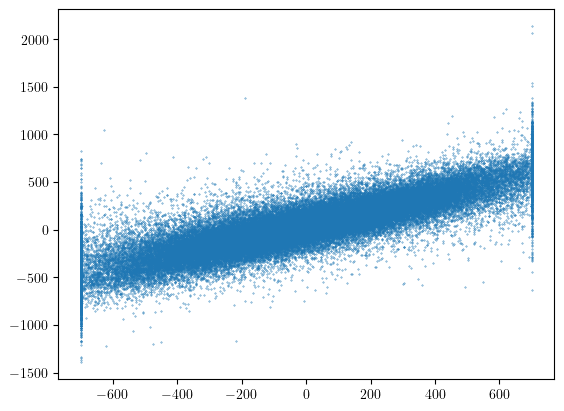

In [ ]:
# vx_all_3D.shape
# delta_box_vel_all_squeezed.shape
pl.figure()
pl.scatter((vx_true_all),(vx_interp_all), s=0.1)



In [ ]:


vx_all_3D_interp = RegularGridInterpolator((xarray, yarray, zarray), vx_all_3D, bounds_error=False)

vx_eval_interp = vx_all_3D_interp(xyz_all_true)


# np.amin(xyz_all_true), np.amax(xyz_all_true)
pl.figure()
pl.scatter(vx_eval_interp*1000, vx_all_true, s=0.1)





In [ ]:
from tqdm import tqdm
isim_fid_array = np.arange(0, 2)
# isim_fid_array = np.arange(3, 11)

vel_clip_min = -700
vel_clip_max = 700
# npart_test = 384**3
npart_test = 512**3


for isim_fid in tqdm(isim_fid_array):
    # isim_fid = 3
    snapnum = 3
    mass_type = 'rockstar_200c'
    snap_dir_base = '/mnt/home/fvillaescusa/ceph/Quijote/Halos/Rockstar/fiducial_HR'
    snapdir = snap_dir_base + '/' + str(isim_fid)  #folder hosting the catalogue
    rockstar = np.loadtxt(snapdir + '/out_' + str(snapnum) + '_pid.list')
    with open(snapdir + '/out_' + str(snapnum) + '_pid.list', 'r') as f:
        lines = f.readlines()
    header = lines[0].split()
    # get the properties of the halos
    pos_h_truth = rockstar[:,header.index('X'):header.index('Z')+1]
    vel_h_truth = rockstar[:,header.index('VX'):header.index('VZ')+1]
    if mass_type == 'rockstar_vir':
        index_M = header.index('Mvir')                    
        mass_truth = rockstar[:,index_M]  #Halo masses in Msun/h
    if mass_type == 'rockstar_200c':
        index_M = header.index('M200c')                    
        mass_truth = rockstar[:,index_M]  #Halo masses in Msun/h

    # Mmin_cut = 1e13
    Mmin_cut = 10**13.5
    lgMass_truth = np.log10(mass_truth)
    indsel = np.where(mass_truth > Mmin_cut)[0]
    # print(grid, len(indsel), len(mass_truth), np.amin(lgMass_truth), np.log10(Mmin_cut))
    pos_h_truth = pos_h_truth[indsel]
    lgMass_truth = lgMass_truth[indsel]
    vel_h_truth = vel_h_truth[indsel]

    vel_h_truth = np.clip(vel_h_truth, vel_clip_min, vel_clip_max)

    # pos_h_truth.shape, mass_truth.shape
    np.random.seed(0)
    import numpy as np
    import h5py as h5
    root = '/mnt/home/spandey/ceph/fastpm/fiducial_HR/hdf5_files/'
    z = {4:0, -1: 99, 3:0.5}[snapnum]
    df = h5.File(root + str(isim_fid) + '/SNAPSHOT_fastpm_B3_z' + str(z) + '.hdf5', 'r')            
    pos_m_truth = df['Position'][:]
    vel_m_truth = df['Velocity'][:]
    # ids_m_truth = np.arange(len(pos_m_truth))
    # get random permutation of indices of particles:


    # npart_test = 256**3
    # npart_test = 512**3
    
    downsample = int(len(pos_m_truth)/npart_test)
    if downsample > 1:
    # select a random subset of particles:
        arg_rand_perm = np.random.permutation(len(pos_m_truth))
        ind = arg_rand_perm[:npart_test]
        pos_m_truth = pos_m_truth[ind]
        vel_m_truth = vel_m_truth[ind]
        # ids_m_truth = ids_m_truth[ind]



    BoxSize = 1000.
    grid = 32
    nMax_m = 32
    Npart = np.float32(np.zeros((grid, grid, grid)))
    MASL.NGP(np.float32(pos_m_truth), Npart, BoxSize)


    # elif grid == 128:
    BoxSize = 1000.
    grid = 32
    nMax_h = 12000
    # dfpart_ngp_wxyz = np.float32(np.zeros((grid, grid, grid, nMax_h, 3)))
    # NGP_xyz(np.float32(pos_m_truth), dfpart_ngp_wxyz, BoxSize)

    # dfpart_ngp_wvxvyvz = np.float32(np.zeros((grid, grid, grid, nMax_h, 3)))
    # NGP_xyz(np.float32(vel_m_truth), dfpart_ngp_wvxvyvz, BoxSize)

    dfpart_ngp_xyz_wvxvyvz = np.float32(np.zeros((grid, grid, grid, nMax_h, 6)))
    NGP_xyz_vel(p.float32(pos_m_truth), np.float32(vel_m_truth), dfpart_ngp_xyz_wvxvyvz, BoxSize)

    dfpart_ngp_wxyz = dfpart_ngp_xyz_wvxvyvz[...,:3]
    dfpart_ngp_wvxvyvz = dfpart_ngp_xyz_wvxvyvz[...,3:]


    from tqdm import tqdm
    norm_delta = 1000     
    norm_vel = 1000     
    grid_sbox = 32
    MAS = 'NGP'
    verbose = False
    delta_box_all = np.zeros((grid, grid, grid, grid_sbox, grid_sbox, grid_sbox, 3))
    delta_box_vel_all = np.zeros((grid, grid, grid, grid_sbox, grid_sbox, grid_sbox, 3, 3))    
    for j1 in tqdm(range(grid)):
        for j2 in range(grid):
            for j3 in range(grid):
                
                if j1 == 0:
                    jn1 = grid - 1
                else:
                    jn1 = j1 - 1
                if j1 == grid - 1:
                    jp1 = 0
                else:
                    jp1 = j1 + 1

                jp1_all = [jn1, j1, jp1]

                if j2 == 0:
                    jn2 = grid - 1
                else:
                    jn2 = j2 - 1

                if j2 == grid - 1:
                    jp2 = 0
                else:
                    jp2 = j2 + 1

                jp2_all = [jn2, j2, jp2]

                if j3 == 0:
                    jn3 = grid - 1
                else:
                    jn3 = j3 - 1

                if j3 == grid - 1:
                    jp3 = 0
                else:
                    jp3 = j3 + 1

                jp3_all = [jn3, j3, jp3]

                coord_add_sign = [-1,0,1]
                all_part = []
                all_part_vel = []                
                for i1 in range(3):
                    for i2 in range(3):
                        for i3 in range(3):
                            all_part_here = dfpart_ngp_wxyz[jp1_all[i1],jp2_all[i2],jp3_all[i3]]
                            all_part_vel_here = dfpart_ngp_wvxvyvz[jp1_all[i1],jp2_all[i2],jp3_all[i3]]

                            indpos = np.where(all_part_here[:,0] != 0)[0]
                            all_part_here = all_part_here[indpos,:]
                            all_part_here[:,0] = all_part_here[:,0] + coord_add_sign[i1]*BoxSize/(grid)
                            all_part_here[:,1] = all_part_here[:,1] + coord_add_sign[i2]*BoxSize/(grid)
                            all_part_here[:,2] = all_part_here[:,2] + coord_add_sign[i3]*BoxSize/(grid)

                            all_part_vel_here = all_part_vel_here[indpos,:] / norm_vel

                            if len(all_part) == 0:
                                all_part = all_part_here
                                all_part_vel = all_part_vel_here
                            else:
                                all_part = np.vstack((all_part, all_part_here))
                                all_part_vel = np.vstack((all_part_vel, all_part_vel_here))



                box_size_sbox = BoxSize/(2*grid)
                all_part0_sel = np.where((all_part[:,0] > -box_size_sbox) & (all_part[:,0] < box_size_sbox) & (all_part[:,1] > -box_size_sbox) & (all_part[:,1] < box_size_sbox) & (all_part[:,2] > -box_size_sbox) & (all_part[:,2] < box_size_sbox))[0]
                all_part0 = all_part[all_part0_sel]
                delta_sbox0 = np.zeros((grid_sbox,grid_sbox,grid_sbox), dtype=np.float32)
                MASL.MA(all_part0 + box_size_sbox, delta_sbox0, (2*box_size_sbox), MAS, verbose=verbose)

                all_part0_vel = all_part_vel[all_part0_sel]
                mom_sbox0_x = np.zeros((grid_sbox,grid_sbox,grid_sbox), dtype=np.float32)
                MASL.MA(all_part0 + box_size_sbox, mom_sbox0_x, (2*box_size_sbox), MAS, W=all_part0_vel[:,0], verbose=verbose)
                mom_sbox0_y = np.zeros((grid_sbox,grid_sbox,grid_sbox), dtype=np.float32)
                MASL.MA(all_part0 + box_size_sbox, mom_sbox0_y, (2*box_size_sbox), MAS, W=all_part0_vel[:,1], verbose=verbose)
                mom_sbox0_z = np.zeros((grid_sbox,grid_sbox,grid_sbox), dtype=np.float32)
                MASL.MA(all_part0 + box_size_sbox, mom_sbox0_z, (2*box_size_sbox), MAS, W=all_part0_vel[:,2], verbose=verbose)

                vel_sbox0_x = mom_sbox0_x/delta_sbox0
                vel_sbox0_y = mom_sbox0_y/delta_sbox0
                vel_sbox0_z = mom_sbox0_z/delta_sbox0

                ind_zeros = np.where(delta_sbox0 == 0)
                vel_sbox0_x[ind_zeros] = 0
                vel_sbox0_y[ind_zeros] = 0
                vel_sbox0_z[ind_zeros] = 0

                vel_sbox0 = np.stack((vel_sbox0_x, vel_sbox0_y, vel_sbox0_z), axis=-1)
                # print('is all vel0 finite:', np.all(np.isfinite(vel_sbox0)))

                nbar0 = (npart_test/BoxSize**3)*((2*box_size_sbox)/grid_sbox)**3
                delta_sbox0 /= nbar0
                delta_sbox0 /= norm_delta




                box_size_sbox = 2*BoxSize/(2*grid)
                all_part1_sel = np.where((all_part[:,0] > -box_size_sbox) & (all_part[:,0] < box_size_sbox) & (all_part[:,1] > -box_size_sbox) & (all_part[:,1] < box_size_sbox) & (all_part[:,2] > -box_size_sbox) & (all_part[:,2] < box_size_sbox))[0]
                all_part1 = all_part[all_part1_sel]
                delta_sbox1 = np.zeros((grid_sbox,grid_sbox,grid_sbox), dtype=np.float32)
                MASL.MA(all_part1 + box_size_sbox, delta_sbox1, (2*box_size_sbox), MAS, verbose=verbose)

                all_part1_vel = all_part_vel[all_part1_sel]
                mom_sbox1_x = np.zeros((grid_sbox,grid_sbox,grid_sbox), dtype=np.float32)
                MASL.MA(all_part1 + box_size_sbox, mom_sbox1_x, (2*box_size_sbox), MAS, W=all_part1_vel[:,0], verbose=verbose)
                mom_sbox1_y = np.zeros((grid_sbox,grid_sbox,grid_sbox), dtype=np.float32)
                MASL.MA(all_part1 + box_size_sbox, mom_sbox1_y, (2*box_size_sbox), MAS, W=all_part1_vel[:,1], verbose=verbose)
                mom_sbox1_z = np.zeros((grid_sbox,grid_sbox,grid_sbox), dtype=np.float32)
                MASL.MA(all_part1 + box_size_sbox, mom_sbox1_z, (2*box_size_sbox), MAS, W=all_part1_vel[:,2], verbose=verbose)
                
                vel_sbox1_x = mom_sbox1_x/delta_sbox1
                vel_sbox1_y = mom_sbox1_y/delta_sbox1
                vel_sbox1_z = mom_sbox1_z/delta_sbox1

                ind_zeros = np.where(delta_sbox1 == 0)
                vel_sbox1_x[ind_zeros] = 0
                vel_sbox1_y[ind_zeros] = 0
                vel_sbox1_z[ind_zeros] = 0

                vel_sbox1 = np.stack((vel_sbox1_x, vel_sbox1_y, vel_sbox1_z), axis=-1)
                # print('is all vel1 finite:', np.all(np.isfinite(vel_sbox1)))

                nbar1 = (npart_test/BoxSize**3)*((2*box_size_sbox)/grid_sbox)**3
                delta_sbox1 /= nbar1
                delta_sbox1 /= norm_delta


                box_size_sbox = 3*BoxSize/(2*grid)
                all_part2 = all_part
                delta_sbox2 = np.zeros((grid_sbox,grid_sbox,grid_sbox), dtype=np.float32)
                MASL.MA(all_part2 + box_size_sbox, delta_sbox2, (2*box_size_sbox), MAS, verbose=verbose)

                all_part2_vel = all_part_vel
                mom_sbox2_x = np.zeros((grid_sbox,grid_sbox,grid_sbox), dtype=np.float32)
                MASL.MA(all_part2 + box_size_sbox, mom_sbox2_x, (2*box_size_sbox), MAS, W=all_part2_vel[:,0], verbose=verbose)
                mom_sbox2_y = np.zeros((grid_sbox,grid_sbox,grid_sbox), dtype=np.float32)
                MASL.MA(all_part2 + box_size_sbox, mom_sbox2_y, (2*box_size_sbox), MAS, W=all_part2_vel[:,1], verbose=verbose)
                mom_sbox2_z = np.zeros((grid_sbox,grid_sbox,grid_sbox), dtype=np.float32)
                MASL.MA(all_part2 + box_size_sbox, mom_sbox2_z, (2*box_size_sbox), MAS, W=all_part2_vel[:,2], verbose=verbose)

                vel_sbox2_x = mom_sbox2_x/delta_sbox2
                vel_sbox2_y = mom_sbox2_y/delta_sbox2
                vel_sbox2_z = mom_sbox2_z/delta_sbox2

                ind_zeros = np.where(delta_sbox2 == 0)
                vel_sbox2_x[ind_zeros] = 0
                vel_sbox2_y[ind_zeros] = 0
                vel_sbox2_z[ind_zeros] = 0

                vel_sbox2 = np.stack((vel_sbox2_x, vel_sbox2_y, vel_sbox2_z), axis=-1)
                # print('is all vel2 finite:', np.all(np.isfinite(vel_sbox2)))
                

                nbar2 = (npart_test/BoxSize**3)*((2*box_size_sbox)/grid_sbox)**3
                delta_sbox2 /= nbar2
                delta_sbox2 /= norm_delta

                delta_sbox_all = np.stack((delta_sbox0, delta_sbox1, delta_sbox2))

                vel_sbox_all = np.stack((vel_sbox0, vel_sbox1, vel_sbox2))

                # move first axis to last:
                delta_sbox_all = np.moveaxis(delta_sbox_all, 0, -1)

                vel_sbox_all = np.moveaxis(vel_sbox_all, 0, -1)

                delta_box_all[j1,j2,j3] = delta_sbox_all
                delta_box_vel_all[j1,j2,j3] = vel_sbox_all


    delta_box_all_squeezed = np.reshape(delta_box_all, (grid*grid*grid, grid_sbox, grid_sbox, grid_sbox, 3))

    delta_box_vel_all_squeezed = np.reshape(delta_box_vel_all, (grid*grid*grid, grid_sbox, grid_sbox, grid_sbox, 3, 3))

    # elif grid == 128:
    BoxSize = 1000.
    grid = 32
    # nMax_h = 42
    nMax_h = 25
    dfhalo_ngp_wxyzM = np.float32(np.zeros((grid, grid, grid, nMax_h, 7)))
    NGP_xyzM_vel(np.float32(pos_h_truth), np.float32(vel_h_truth), np.float32(lgMass_truth), dfhalo_ngp_wxyzM, BoxSize)


    # dfhalo_ngp_wxyzM_squeezed = np.reshape(dfhalo_ngp_wxyzM, (grid*grid*grid, nMax_h, 4))
    Nhalos_truth = np.float32(np.zeros((grid, grid, grid)))
    MASL.NGP(np.float32(pos_h_truth), Nhalos_truth, BoxSize)

    M_halos_argsort = np.flip(np.argsort(dfhalo_ngp_wxyzM[:,:,:,:,-1], axis=-1), axis=-1)
    xmin = BoxSize/grid/2
    lgMin = np.log10(Mmin_cut)
    lgMax = 15.5
    dfhalo_ngp_xyzM_sorted_scaled = np.zeros_like(dfhalo_ngp_wxyzM)
    for i1 in range(grid):
        for i2 in range(grid):
            for i3 in range(grid):
                for jc in range(0,3):
                    dfhalo_ngp_xyzM_sorted_scaled[i1, i2, i3, :, jc] = dfhalo_ngp_wxyzM[i1, i2, i3, M_halos_argsort[i1, i2, i3], jc]
                    indpos_x = np.where(dfhalo_ngp_xyzM_sorted_scaled[i1, i2, i3, :, jc] != 0.0)[0]
                    dfhalo_ngp_xyzM_sorted_scaled[i1, i2, i3, indpos_x, jc] = (dfhalo_ngp_xyzM_sorted_scaled[i1, i2, i3, indpos_x, jc] + xmin)/(2*xmin)

                for jc in range(3,6):
                    dfhalo_ngp_xyzM_sorted_scaled[i1, i2, i3, :, jc] = dfhalo_ngp_wxyzM[i1, i2, i3, M_halos_argsort[i1, i2, i3], jc]
                    indpos_x = np.where(dfhalo_ngp_xyzM_sorted_scaled[i1, i2, i3, :, jc] != 0.0)[0]
                    dfhalo_ngp_xyzM_sorted_scaled[i1, i2, i3, indpos_x, jc] = (dfhalo_ngp_xyzM_sorted_scaled[i1, i2, i3, indpos_x, jc] - 1.01*vel_clip_min)/(vel_clip_max - vel_clip_min)


                dfhalo_ngp_xyzM_sorted_scaled[i1, i2, i3, :, 6] = dfhalo_ngp_wxyzM[i1, i2, i3, M_halos_argsort[i1, i2, i3], 6]
                indpos_M = np.where(dfhalo_ngp_xyzM_sorted_scaled[i1, i2, i3, :, 6] != 0.0)[0]
                dfhalo_ngp_xyzM_sorted_scaled[i1, i2, i3, indpos_M, 6] = (dfhalo_ngp_xyzM_sorted_scaled[i1, i2, i3, indpos_M, 6] - lgMin)/(lgMax - lgMin)



    indzeros = np.where(dfhalo_ngp_xyzM_sorted_scaled == 0.0)
    dfhalo_ngp_xyzM_sorted_scaled[indzeros] = -1.0


    # np.amin(dfhalo_ngp_xyzM_sorted_scaled), np.amax(dfhalo_ngp_xyzM_sorted_scaled)
    # nvocab = 96
    nvocab = 64
    bins_digitize = np.linspace(-1e-3, 1, nvocab)
    # bins_digitize.insert(0, -1)
    bins_digitize = np.insert(bins_digitize, 0, -1)
    # bins_digitize
    dfhalo_ngp_xyzM_sorted_scaled_digitized = np.digitize(dfhalo_ngp_xyzM_sorted_scaled, bins_digitize)

    start_token = 0
    pad_token = 1
    end_token = nvocab + 1
    space_token = nvocab + 2
    max_sentence_length = 1 + nMax_h*7 + 1 + (nMax_h-1)
    dfhalo_ngp_xyzM_tokenized = np.zeros((grid, grid, grid, max_sentence_length), dtype=np.int32) + end_token

    dfhalo_ngp_xyzM_tokenized[..., 0] = start_token
    # for jh in range(nMax_h):
    jh = 1
    while jh < 8*nMax_h:
        # if dfhalo_ngp_xyzM_sorted_scaled_digitized[..., jh, 0] > 1:
        dfhalo_ngp_xyzM_tokenized[..., jh + 0] = dfhalo_ngp_xyzM_sorted_scaled_digitized[..., jh//8, -1]
        for jc in range(0,6):
            dfhalo_ngp_xyzM_tokenized[..., jh + jc + 1] = dfhalo_ngp_xyzM_sorted_scaled_digitized[..., jh//8, jc]
        # dfhalo_ngp_xyzM_tokenized[..., jh + 2] = dfhalo_ngp_xyzM_sorted_scaled_digitized[..., jh//5, 1]
        # dfhalo_ngp_xyzM_tokenized[..., jh + 3] = dfhalo_ngp_xyzM_sorted_scaled_digitized[..., jh//5, 2]



        if jh//8 < nMax_h - 1:
            # dfhalo_ngp_xyzM_tokenized[..., jh + 4] = space_token
            dfhalo_ngp_xyzM_tokenized[..., jh + 7] = space_token            
        # else:
        #     dfhalo_ngp_xyzM_tokenized[..., 1 + nMax_h*4] = end_token
        # jh += 5
        jh += 8



    dfhalo_ngp_xyzM_tokenized_padded_ended = np.copy(dfhalo_ngp_xyzM_tokenized)
    for i1 in range(grid):
        for i2 in range(grid):
            for i3 in range(grid):
                ind1 = np.where(dfhalo_ngp_xyzM_tokenized[i1, i2, i3,:] == 1)[0]
                try:
                    ind1 = ind1[0]
                    if ind1 == 1:
                        dfhalo_ngp_xyzM_tokenized_padded_ended[i1, i2, i3, ind1] = end_token
                        dfhalo_ngp_xyzM_tokenized_padded_ended[i1, i2, i3, ind1+1:] = pad_token
                    else:
                        dfhalo_ngp_xyzM_tokenized_padded_ended[i1, i2, i3, ind1-1] = end_token
                        dfhalo_ngp_xyzM_tokenized_padded_ended[i1, i2, i3, ind1:] = pad_token
                except:
                    dfhalo_ngp_xyzM_tokenized_padded_ended[i1, i2, i3, ind1-1] = end_token
                    # dfhalo_ngp_xyzM_tokenized_padded_ended[i1, i2, i3, ind1:] = pad_token



    dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed = np.reshape(dfhalo_ngp_xyzM_tokenized_padded_ended, (grid*grid*grid, max_sentence_length))
    # dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed.shape

    # dfhalo_ngp_wxyzM_flatten = np.reshape(dfhalo_ngp_wxyzM, (grid*grid*grid, nMax_h, 4))
    dfhalo_ngp_wxyzM_flatten = np.reshape(dfhalo_ngp_wxyzM, (grid*grid*grid, nMax_h, 7))    
    Nhalos_truth_flatten = np.reshape(Nhalos_truth, (grid*grid*grid,))


    saved = {'dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed':dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed.astype(np.int16),
            'dfhalo_ngp_wxyzM': dfhalo_ngp_wxyzM.astype(np.float32),
            'Nhalos_truth': Nhalos_truth.astype(np.int16),
            'delta_box_all_squeezed': delta_box_all_squeezed.astype(np.float32),
            'delta_box_vel_all_squeezed': delta_box_vel_all_squeezed.astype(np.float32),
            'nvocab_total': nvocab + 3,
            'max_sentence_length': max_sentence_length,
            'grid': grid,
            'nMax_h': nMax_h,
            'BoxSize': BoxSize,
            'lgMin': lgMin,
            'lgMax': lgMax,
            'xmin': xmin,
            'norm_delta': norm_delta,
            'start_token': start_token,
            'pad_token': pad_token,
            'end_token': end_token,
            'space_token': space_token
            }

    # pk.dump(saved, open(f'/mnt/home/spandey/ceph/CHARFORMER/data/PM/df_halo_part_ngp_xyz_vel_M_tokenized_PM_384x384x384_density3Dgrid_{grid_sbox}_isim_{isim_fid}_snap_{snapnum}_nvocab64_Mmin_1e13p5.pkl', 'wb'))    
    pk.dump(saved, open(f'/mnt/home/spandey/ceph/CHARFORMER/data/PM/df_halo_part_ngp_xyz_vel_M_tokenized_PM_512x512x512_density3Dgrid_{grid_sbox}_isim_{isim_fid}_snap_{snapnum}_nvocab{nvocab}_Mmin_1e13p5.pkl', 'wb'))        




  0%|          | 0/2 [00:00<?, ?it/s]

/tmp/ipykernel_204525/2213119669.py:33: RuntimeWarning: divide by zero encountered in log10
  lgMass_truth = np.log10(mass_truth)


In [ ]:
from tqdm import tqdm
import h5py as h5
isim_fid_array = np.arange(0, 2)
# isim_fid_array = np.arange(3, 11)

vel_clip_min = -700
vel_clip_max = 700
nvocab = 64
# npart_test = 384**3
# npart_test = 512**3


for isim_fid in tqdm(isim_fid_array):
    # isim_fid = 3
    snapnum = 3
    mass_type = 'rockstar_200c'
    snap_dir_base = '/mnt/home/fvillaescusa/ceph/Quijote/Halos/Rockstar/fiducial_HR'
    snapdir = snap_dir_base + '/' + str(isim_fid)  #folder hosting the catalogue
    rockstar = np.loadtxt(snapdir + '/out_' + str(snapnum) + '_pid.list')
    with open(snapdir + '/out_' + str(snapnum) + '_pid.list', 'r') as f:
        lines = f.readlines()
    header = lines[0].split()
    # get the properties of the halos
    pos_h_truth = rockstar[:,header.index('X'):header.index('Z')+1]
    vel_h_truth = rockstar[:,header.index('VX'):header.index('VZ')+1]
    if mass_type == 'rockstar_vir':
        index_M = header.index('Mvir')                    
        mass_truth = rockstar[:,index_M]  #Halo masses in Msun/h
    if mass_type == 'rockstar_200c':
        index_M = header.index('M200c')                    
        mass_truth = rockstar[:,index_M]  #Halo masses in Msun/h

    # Mmin_cut = 1e13
    Mmin_cut = 10**13.5
    lgMass_truth = np.log10(mass_truth)
    indsel = np.where(mass_truth > Mmin_cut)[0]
    # print(grid, len(indsel), len(mass_truth), np.amin(lgMass_truth), np.log10(Mmin_cut))
    pos_h_truth = pos_h_truth[indsel]
    lgMass_truth = lgMass_truth[indsel]
    vel_h_truth = vel_h_truth[indsel]

    vel_h_truth = np.clip(vel_h_truth, vel_clip_min, vel_clip_max)

    BoxSize = 1000.
    grid = 32
    # nMax_h = 42
    nMax_h = 25
    dfhalo_ngp_wxyzM = np.float32(np.zeros((grid, grid, grid, nMax_h, 7)))
    NGP_xyzM_vel(np.float32(pos_h_truth), np.float32(vel_h_truth), np.float32(lgMass_truth), dfhalo_ngp_wxyzM, BoxSize)


    # dfhalo_ngp_wxyzM_squeezed = np.reshape(dfhalo_ngp_wxyzM, (grid*grid*grid, nMax_h, 4))
    Nhalos_truth = np.float32(np.zeros((grid, grid, grid)))
    MASL.NGP(np.float32(pos_h_truth), Nhalos_truth, BoxSize)

    M_halos_argsort = np.flip(np.argsort(dfhalo_ngp_wxyzM[:,:,:,:,-1], axis=-1), axis=-1)
    xmin = BoxSize/grid/2
    lgMin = np.log10(Mmin_cut)
    lgMax = 15.5
    dfhalo_ngp_xyzM_sorted_scaled = np.zeros_like(dfhalo_ngp_wxyzM)
    for i1 in range(grid):
        for i2 in range(grid):
            for i3 in range(grid):
                for jc in range(0,3):
                    dfhalo_ngp_xyzM_sorted_scaled[i1, i2, i3, :, jc] = dfhalo_ngp_wxyzM[i1, i2, i3, M_halos_argsort[i1, i2, i3], jc]
                    indpos_x = np.where(dfhalo_ngp_xyzM_sorted_scaled[i1, i2, i3, :, jc] != 0.0)[0]
                    dfhalo_ngp_xyzM_sorted_scaled[i1, i2, i3, indpos_x, jc] = (dfhalo_ngp_xyzM_sorted_scaled[i1, i2, i3, indpos_x, jc] + xmin)/(2*xmin)

                for jc in range(3,6):
                    dfhalo_ngp_xyzM_sorted_scaled[i1, i2, i3, :, jc] = dfhalo_ngp_wxyzM[i1, i2, i3, M_halos_argsort[i1, i2, i3], jc]
                    indpos_x = np.where(dfhalo_ngp_xyzM_sorted_scaled[i1, i2, i3, :, jc] != 0.0)[0]
                    # if i1 == 0 and i2 == 0 and i3 == 9 and jc == 5:
                    #     import pdb; pdb.set_trace()
                    dfhalo_ngp_xyzM_sorted_scaled[i1, i2, i3, indpos_x, jc] = (dfhalo_ngp_xyzM_sorted_scaled[i1, i2, i3, indpos_x, jc] - 1.01*vel_clip_min)/(1.01*(vel_clip_max - vel_clip_min))


                dfhalo_ngp_xyzM_sorted_scaled[i1, i2, i3, :, 6] = dfhalo_ngp_wxyzM[i1, i2, i3, M_halos_argsort[i1, i2, i3], 6]
                indpos_M = np.where(dfhalo_ngp_xyzM_sorted_scaled[i1, i2, i3, :, 6] != 0.0)[0]
                dfhalo_ngp_xyzM_sorted_scaled[i1, i2, i3, indpos_M, 6] = (dfhalo_ngp_xyzM_sorted_scaled[i1, i2, i3, indpos_M, 6] - lgMin)/(lgMax - lgMin)



    indzeros = np.where(dfhalo_ngp_xyzM_sorted_scaled == 0.0)
    dfhalo_ngp_xyzM_sorted_scaled[indzeros] = -1.0


    # np.amin(dfhalo_ngp_xyzM_sorted_scaled), np.amax(dfhalo_ngp_xyzM_sorted_scaled)
    # nvocab = 96
    # nvocab = 64
    bins_digitize = np.linspace(-1e-3, 1, nvocab)
    # bins_digitize.insert(0, -1)
    bins_digitize = np.insert(bins_digitize, 0, -1)
    # bins_digitize[2] = -1e-5
    # bins_digitize
    dfhalo_ngp_xyzM_sorted_scaled_digitized = np.digitize(dfhalo_ngp_xyzM_sorted_scaled, bins_digitize)

    start_token = 0
    pad_token = 1
    end_token = nvocab + 1
    space_token = nvocab + 2
    max_sentence_length = 1 + nMax_h*7 + 1 + (nMax_h-1)
    dfhalo_ngp_xyzM_tokenized = np.zeros((grid, grid, grid, max_sentence_length), dtype=np.int32) + end_token

    dfhalo_ngp_xyzM_tokenized[..., 0] = start_token
    # for jh in range(nMax_h):
    jh = 1
    while jh < 8*nMax_h:
        # if dfhalo_ngp_xyzM_sorted_scaled_digitized[..., jh, 0] > 1:
        dfhalo_ngp_xyzM_tokenized[..., jh + 0] = dfhalo_ngp_xyzM_sorted_scaled_digitized[..., jh//8, -1]
        for jc in range(0,6):
            dfhalo_ngp_xyzM_tokenized[..., jh + jc + 1] = dfhalo_ngp_xyzM_sorted_scaled_digitized[..., jh//8, jc]
        # dfhalo_ngp_xyzM_tokenized[..., jh + 2] = dfhalo_ngp_xyzM_sorted_scaled_digitized[..., jh//5, 1]
        # dfhalo_ngp_xyzM_tokenized[..., jh + 3] = dfhalo_ngp_xyzM_sorted_scaled_digitized[..., jh//5, 2]



        if jh//8 < nMax_h - 1:
            # dfhalo_ngp_xyzM_tokenized[..., jh + 4] = space_token
            dfhalo_ngp_xyzM_tokenized[..., jh + 7] = space_token            
        # else:
        #     dfhalo_ngp_xyzM_tokenized[..., 1 + nMax_h*4] = end_token
        # jh += 5
        jh += 8





    dfhalo_ngp_xyzM_tokenized_padded_ended = np.copy(dfhalo_ngp_xyzM_tokenized)
    for i1 in range(grid):
        for i2 in range(grid):
            for i3 in range(grid):
                ind1 = np.where(dfhalo_ngp_xyzM_tokenized[i1, i2, i3,:] == 1)[0]
                try:
                    ind1 = ind1[0]
                    if ind1 == 1:
                        dfhalo_ngp_xyzM_tokenized_padded_ended[i1, i2, i3, ind1] = end_token
                        dfhalo_ngp_xyzM_tokenized_padded_ended[i1, i2, i3, ind1+1:] = pad_token
                    else:
                        dfhalo_ngp_xyzM_tokenized_padded_ended[i1, i2, i3, ind1-1] = end_token
                        dfhalo_ngp_xyzM_tokenized_padded_ended[i1, i2, i3, ind1:] = pad_token
                except:
                    dfhalo_ngp_xyzM_tokenized_padded_ended[i1, i2, i3, ind1-1] = end_token

    dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed = np.reshape(dfhalo_ngp_xyzM_tokenized_padded_ended, (grid*grid*grid, max_sentence_length))

    dfhalo_ngp_wxyzM_flatten = np.reshape(dfhalo_ngp_wxyzM, (grid*grid*grid, nMax_h, 7))    
    Nhalos_truth_flatten = np.reshape(Nhalos_truth, (grid*grid*grid,))

    f0 = h5.File(f'/mnt/home/spandey/ceph/CHARFORMER/data/PM/df_halo_part_ngp_xyz_vel_M_tokenized_PM_512x512x512_density3Dgrid_32_isim_{isim_fid}_snap_3_nvocab96_Mmin_13p5.h5', 'r')
    delta_vel_box_all_squeezed_all = f0['delta_vel_box_all_squeezed_all'][()]
    f = h5.File(f'/mnt/home/spandey/ceph/CHARFORMER/data/PM/df_halo_part_ngp_xyz_vel_M_tokenized_PM_512x512x512_density3Dgrid_32_isim_{isim_fid}_snap_3_nvocab64_Mmin_1e13p5.h5', 'w')
    f.create_dataset('dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed_all', data=dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed)
    f.create_dataset('delta_vel_box_all_squeezed_all', data=delta_vel_box_all_squeezed_all)
    f.create_dataset('dfhalo_ngp_wxyzM_reshape_all', data=dfhalo_ngp_wxyzM_flatten)
    f.create_dataset('Nhalos_truth_reshape_all', data=Nhalos_truth_flatten)
    f.create_dataset('nvocab_total', data=nvocab + 3)
    f.create_dataset('max_sentence_length', data=max_sentence_length)
    f.create_dataset('grid', data=f0['grid'][()])
    f.create_dataset('nMax_h', data=f0['nMax_h'][()])
    f.create_dataset('BoxSize', data=f0['BoxSize'][()])
    f.create_dataset('lgMin', data=f0['lgMin'][()])
    f.create_dataset('lgMax', data=f0['lgMax'][()])
    f.create_dataset('xmin', data=f0['xmin'][()])
    f.create_dataset('norm_delta', data=f0['norm_delta'][()])
    f.create_dataset('start_token', data=start_token)
    f.create_dataset('pad_token', data=pad_token)
    f.create_dataset('end_token', data=end_token)
    f.create_dataset('space_token', data=space_token)
    f.close()
    f0.close()




  0%|          | 0/2 [00:00<?, ?it/s]

/tmp/ipykernel_2898338/3783712663.py:35: RuntimeWarning: divide by zero encountered in log10
  lgMass_truth = np.log10(mass_truth)
100%|██████████| 2/2 [07:05<00:00, 212.72s/it]


In [ ]:
dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed[9,:]


array([ 0, 22, 14, 29, 28, 35, 22, 23, 66, 21, 38, 38, 55, 30, 34, 18, 66,
        5, 57,  8,  6, 31, 30, 28, 66,  4, 44, 41, 41, 21, 34, 20, 66,  4,
       47, 14, 18, 28, 33,  2, 66,  4, 26, 29, 36, 25, 21,  8, 65,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1],
      dtype=int32)

In [ ]:
delta_vel_box_all_squeezed_all.shape, dfhalo_ngp_wxyzM_flatten.shape


((32768, 12, 32, 32, 32), (32768, 25, 7))

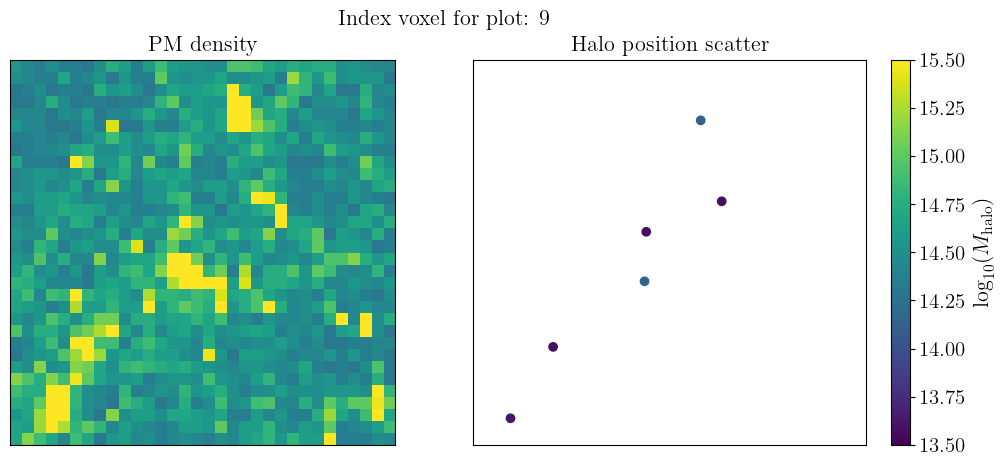

In [ ]:
fig, (ax2, ax3) = pl.subplots(1, 2, figsize=(13, 5))

# indp = ind_full[0]
indp = 9
# ax2.imshow(np.sum(delta_box_all_squeezed[indp,:,:,:,0], axis=0).T, origin='lower', vmin=0.0, vmax=0.5)
ax2.imshow(np.sum(delta_vel_box_all_squeezed_all[indp,0,:,:, :], axis=0).T, origin='lower', vmin=-0.1, vmax=0.15)
ax2.set_title('PM density', size=16)
# pl.colorbar()
ax2.set_xticks([])
ax2.set_yticks([])

scatter = ax3.scatter(dfhalo_ngp_wxyzM_flatten[indp,:,1][:int(Nhalos_truth_flatten[indp])], dfhalo_ngp_wxyzM_flatten[indp,:,2][:int(Nhalos_truth_flatten[indp])], c=dfhalo_ngp_wxyzM_flatten[indp,:,-1][:int(Nhalos_truth_flatten[indp])], cmap='viridis', vmin=13.5, vmax=15.5)
ax3.set_xlim(-xmin, xmin)
ax3.set_ylim(-xmin, xmin)
ax3.set_title('Halo position scatter', size=16)
ax3.set_xticks([])
ax3.set_yticks([])

cbar = pl.colorbar(scatter, ax=ax3)
cbar.set_label(r'$\log_{10}(M_{\rm halo})$', size=16)
cbar.ax.tick_params(labelsize=15)

pl.suptitle(f'Index voxel for plot: {indp}', size=16)
pl.subplots_adjust(wspace=0.05)



array([ 0, 13, 31, 21,  9, 29, 42, 42, 66, 12, 40, 41, 47, 30, 38, 35, 66,
        5, 20, 38, 24, 40, 39, 40, 66,  2, 22, 52, 38, 26, 43, 36, 65,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1], dtype=int32)

In [ ]:
ind_full = np.where(dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed[:,-1] == end_token)[0]


In [ ]:
delta_box_vel_all_squeezed.shape


(32768, 32, 32, 32, 3, 3)

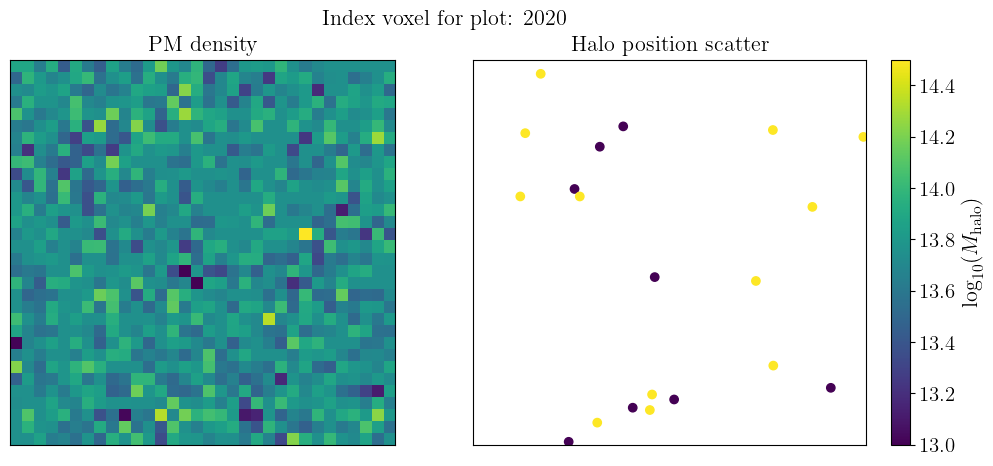

In [ ]:
fig, (ax2, ax3) = pl.subplots(1, 2, figsize=(13, 5))

indp = ind_full[0]
# indp = 143
# ax2.imshow(np.sum(delta_box_all_squeezed[indp,:,:,:,0], axis=0).T, origin='lower', vmin=0.0, vmax=0.5)
ax2.imshow(np.sum(delta_box_vel_all_squeezed[indp,:,:,:,0, 0], axis=0).T, origin='lower', vmin=-0.05, vmax=0.05)
ax2.set_title('PM density', size=16)
# pl.colorbar()
ax2.set_xticks([])
ax2.set_yticks([])

scatter = ax3.scatter(dfhalo_ngp_wxyzM_flatten[indp,:,1][:int(Nhalos_truth_flatten[indp])], dfhalo_ngp_wxyzM_flatten[indp,:,2][:int(Nhalos_truth_flatten[indp])], c=dfhalo_ngp_wxyzM_flatten[indp,:,3][:int(Nhalos_truth_flatten[indp])], cmap='viridis', vmin=13, vmax=14.5)
ax3.set_xlim(-xmin, xmin)
ax3.set_ylim(-xmin, xmin)
ax3.set_title('Halo position scatter', size=16)
ax3.set_xticks([])
ax3.set_yticks([])

cbar = pl.colorbar(scatter, ax=ax3)
cbar.set_label(r'$\log_{10}(M_{\rm halo})$', size=16)
cbar.ax.tick_params(labelsize=15)

pl.suptitle(f'Index voxel for plot: {indp}', size=16)
pl.subplots_adjust(wspace=0.05)



In [ ]:
fig, (ax2, ax3) = pl.subplots(1, 2, figsize=(13, 5))

indp = ind_full[0]
# indp = 143
ax2.imshow(np.sum(delta_box_all_squeezed[indp,:,:,:,0], axis=0).T, origin='lower', vmin=0.0, vmax=0.5)
ax2.set_title('PM density', size=16)
# pl.colorbar()
ax2.set_xticks([])
ax2.set_yticks([])

scatter = ax3.scatter(dfhalo_ngp_wxyzM_flatten[indp,:,1][:int(Nhalos_truth_flatten[indp])], dfhalo_ngp_wxyzM_flatten[indp,:,2][:int(Nhalos_truth_flatten[indp])], c=dfhalo_ngp_wxyzM_flatten[indp,:,-1][:int(Nhalos_truth_flatten[indp])], cmap='viridis', vmin=13, vmax=14.5)
ax3.set_xlim(-xmin, xmin)
ax3.set_ylim(-xmin, xmin)
ax3.set_title('Halo position scatter', size=16)
ax3.set_xticks([])
ax3.set_yticks([])

cbar = pl.colorbar(scatter, ax=ax3)
cbar.set_label(r'$\log_{10}(M_{\rm halo})$', size=16)
cbar.ax.tick_params(labelsize=15)

pl.suptitle(f'Index voxel for plot: {indp}', size=16)
pl.subplots_adjust(wspace=0.05)



In [ ]:
            # 'dfhalo_ngp_wxyzM': dfhalo_ngp_wxyzM.astype(np.float32),
            # 'Nhalos_truth': Nhalos_truth.astype(np.int16),
            # 'delta_box_all_squeezed': delta_box_all_squeezed.astype(np.float32),
            # 'delta_box_vel_all_squeezed': delta_box_vel_all_squeezed.astype(np.float32),
            # 'nvocab_total': nvocab + 3,
            # 'max_sentence_length': max_sentence_length,
            # 'grid': grid,
            # 'nMax_h': nMax_h,
            # 'BoxSize': BoxSize,
            # 'lgMin': lgMin,
            # 'lgMax': lgMax,
            # 'xmin': xmin,
            # 'norm_delta': norm_delta,
            # 'start_token': start_token,
            # 'pad_token': pad_token,
            # 'end_token': end_token,
            # 'space_token': space_token

In [ ]:
import gc
import pickle as pk
import numpy as np
df = pk.load(open('/mnt/home/spandey/ceph/CHARFORMER/data/PM/df_halo_part_ngp_xyz_vel_M_tokenized_PM_384x384x384_density3Dgrid_32_isim_0_snap_3_nvocab64_Mmin_1e13p5.pkl','rb'))

dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed_0 = df['dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed']
dfhalo_ngp_wxyzM_0 = df['dfhalo_ngp_wxyzM']
Nhalos_truth_0 = df['Nhalos_truth']
delta_box_all_squeezed_0 = df['delta_box_all_squeezed']
delta_box_vel_all_squeezed_0 = df['delta_box_vel_all_squeezed'].reshape(delta_box_all_squeezed_0.shape[0], delta_box_all_squeezed_0.shape[1], delta_box_all_squeezed_0.shape[2], delta_box_all_squeezed_0.shape[3], 9)
delta_vel_box_all_squeezed_0 = np.concatenate((delta_box_all_squeezed_0, delta_box_vel_all_squeezed_0), axis=-1)
delta_box_vel_all_squeezed_0 = 0
del delta_box_vel_all_squeezed_0
gc.collect()

df = pk.load(open('/mnt/home/spandey/ceph/CHARFORMER/data/PM/df_halo_part_ngp_xyz_vel_M_tokenized_PM_384x384x384_density3Dgrid_32_isim_1_snap_3_nvocab64_Mmin_1e13p5.pkl','rb'))
dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed_1 = df['dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed']
dfhalo_ngp_wxyzM_1 = df['dfhalo_ngp_wxyzM']
Nhalos_truth_1 = df['Nhalos_truth']
delta_box_all_squeezed_1= df['delta_box_all_squeezed']
delta_box_vel_all_squeezed_1 = df['delta_box_vel_all_squeezed'].reshape(delta_box_all_squeezed_0.shape[0], delta_box_all_squeezed_0.shape[1], delta_box_all_squeezed_0.shape[2], delta_box_all_squeezed_0.shape[3], 9)
delta_vel_box_all_squeezed_1 = np.concatenate((delta_box_all_squeezed_1, delta_box_vel_all_squeezed_1), axis=-1)
delta_box_vel_all_squeezed_1 = 0
del delta_box_vel_all_squeezed_1
gc.collect()

# df = pk.load(open('/mnt/home/spandey/ceph/CHARFORMER/data/PM/df_halo_part_ngp_xyzM_tokenized_PM_384x384x384_density3Dgrid_32_isim_2_snap_3_FINAL.pkl','rb'))
# df = pk.load(open('/mnt/home/spandey/ceph/CHARFORMER/data/PM/df_halo_part_ngp_xyzM_tokenized_PM_384x384x384_density3Dgrid_32_isim_2_snap_3_nvocab64_Mmin_1e13p5.pkl','rb'))
df = pk.load(open('/mnt/home/spandey/ceph/CHARFORMER/data/PM/df_halo_part_ngp_xyz_vel_M_tokenized_PM_384x384x384_density3Dgrid_32_isim_2_snap_3_nvocab64_Mmin_1e13p5.pkl','rb'))
dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed_2 = df['dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed']
dfhalo_ngp_wxyzM_2 = df['dfhalo_ngp_wxyzM']
Nhalos_truth_2 = df['Nhalos_truth']
delta_box_all_squeezed_2 = df['delta_box_all_squeezed']
delta_box_vel_all_squeezed_2 = df['delta_box_vel_all_squeezed'].reshape(delta_box_all_squeezed_0.shape[0], delta_box_all_squeezed_0.shape[1], delta_box_all_squeezed_0.shape[2], delta_box_all_squeezed_0.shape[3], 9)
delta_vel_box_all_squeezed_2 = np.concatenate((delta_box_all_squeezed_2, delta_box_vel_all_squeezed_2), axis=-1)
delta_box_vel_all_squeezed_2 = 0
del delta_box_vel_all_squeezed_2
gc.collect()




FileNotFoundError: [Errno 2] No such file or directory: '/mnt/home/spandey/ceph/CHARFORMER/data/PM/df_halo_part_ngp_xyz_vel_M_tokenized_PM_384x384x384_density3Dgrid_32_isim_2_snap_3_nvocab64.pkl'

In [ ]:
dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed_all = np.vstack((dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed_0, dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed_1, dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed_2)).astype(np.int16)





In [ ]:
delta_vel_box_all_squeezed_all = np.vstack((delta_vel_box_all_squeezed_0, delta_vel_box_all_squeezed_1, delta_vel_box_all_squeezed_2)).astype(np.float32)
delta_vel_box_all_squeezed_all = np.moveaxis(delta_vel_box_all_squeezed_all, -1, 1)




In [ ]:
nMax_h = df['nMax_h']
grid = df['grid']



In [ ]:
grid = dfhalo_ngp_wxyzM_0.shape[0]
dfhalo_ngp_wxyzM_0_reshape = np.reshape(dfhalo_ngp_wxyzM_0, (grid*grid*grid, nMax_h, 7))
dfhalo_ngp_wxyzM_1_reshape = np.reshape(dfhalo_ngp_wxyzM_1, (grid*grid*grid, nMax_h, 7))
dfhalo_ngp_wxyzM_2_reshape = np.reshape(dfhalo_ngp_wxyzM_2, (grid*grid*grid, nMax_h, 7))
dfhalo_ngp_wxyzM_reshape_all = np.vstack((dfhalo_ngp_wxyzM_0_reshape, dfhalo_ngp_wxyzM_1_reshape, dfhalo_ngp_wxyzM_2_reshape)).astype(np.float32)




In [ ]:
Nhalos_truth_0_reshape = np.reshape(Nhalos_truth_0, (grid*grid*grid))
Nhalos_truth_1_reshape = np.reshape(Nhalos_truth_1, (grid*grid*grid))
Nhalos_truth_2_reshape = np.reshape(Nhalos_truth_2, (grid*grid*grid))
Nhalos_truth_reshape_all = np.concatenate((Nhalos_truth_0_reshape, Nhalos_truth_1_reshape, Nhalos_truth_2_reshape)).astype(np.int16)




In [ ]:
import h5py as h5
# f = h5.File('/mnt/home/spandey/ceph/CHARFORMER/data/PM/df_halo_part_ngp_xyzM_tokenized_PM_384x384x384_density3Dgrid_32_isim_012_snap_3_FINAL.h5', 'w')
# f = h5.File('/mnt/home/spandey/ceph/CHARFORMER/data/PM/df_halo_part_ngp_xyzM_tokenized_PM_384x384x384_density3Dgrid_32_isim_012_snap_3_nvocab64_Mmin_13p5.h5', 'w')
f = h5.File('/mnt/home/spandey/ceph/CHARFORMER/data/PM/df_halo_part_ngp_xyz_vel_M_tokenized_PM_384x384x384_density3Dgrid_32_isim_012_snap_3_nvocab64_Mmin_13p5.h5', 'w')
f.create_dataset('dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed_all', data=dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed_all)
f.create_dataset('delta_vel_box_all_squeezed_all', data=delta_vel_box_all_squeezed_all)
f.create_dataset('dfhalo_ngp_wxyzM_reshape_all', data=dfhalo_ngp_wxyzM_reshape_all)
f.create_dataset('Nhalos_truth_reshape_all', data=Nhalos_truth_reshape_all)
f.create_dataset('nvocab_total', data=df['nvocab_total'])
f.create_dataset('max_sentence_length', data=df['max_sentence_length'])
f.create_dataset('grid', data=df['grid'])
f.create_dataset('nMax_h', data=df['nMax_h'])
f.create_dataset('BoxSize', data=df['BoxSize'])
f.create_dataset('lgMin', data=df['lgMin'])
f.create_dataset('lgMax', data=df['lgMax'])
f.create_dataset('xmin', data=df['xmin'])
f.create_dataset('norm_delta', data=df['norm_delta'])
f.create_dataset('start_token', data=df['start_token'])
f.create_dataset('pad_token', data=df['pad_token'])
f.create_dataset('end_token', data=df['end_token'])
f.create_dataset('space_token', data=df['space_token'])
f.close()




In [ ]:
import h5py as h5
f = h5.File('/mnt/home/spandey/ceph/CHARFORMER/data/PM/df_halo_part_ngp_xyz_vel_M_tokenized_PM_384x384x384_density3Dgrid_32_isim_012_snap_3_nvocab64_Mmin_13p5.h5', 'r')



In [ ]:
delta_vel_box_all_squeezed_all = f['delta_vel_box_all_squeezed_all'][:]




In [ ]:
import gc
import pickle as pk
import numpy as np
nvocab = 96
for isim in range(0, 2):

    # df = pk.load(open(f'/mnt/home/spandey/ceph/CHARFORMER/data/PM/df_halo_part_ngp_xyz_vel_M_tokenized_PM_384x384x384_density3Dgrid_32_isim_{isim}_snap_3_nvocab64_Mmin_1e13p5.pkl','rb'))
    df = pk.load(open(f'/mnt/home/spandey/ceph/CHARFORMER/data/PM/df_halo_part_ngp_xyz_vel_M_tokenized_PM_512x512x512_density3Dgrid_32_isim_{isim}_snap_3_nvocab{nvocab}_Mmin_1e13p5.pkl','rb'))    

    dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed_0 = df['dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed']
    dfhalo_ngp_wxyzM_0 = df['dfhalo_ngp_wxyzM']
    Nhalos_truth_0 = df['Nhalos_truth']
    delta_box_all_squeezed_0 = df['delta_box_all_squeezed']
    delta_box_vel_all_squeezed_0 = df['delta_box_vel_all_squeezed'].reshape(delta_box_all_squeezed_0.shape[0], delta_box_all_squeezed_0.shape[1], delta_box_all_squeezed_0.shape[2], delta_box_all_squeezed_0.shape[3], 9)
    delta_vel_box_all_squeezed_0 = np.concatenate((delta_box_all_squeezed_0, delta_box_vel_all_squeezed_0), axis=-1)
    delta_box_vel_all_squeezed_0 = 0
    del delta_box_vel_all_squeezed_0
    gc.collect()

    delta_vel_box_all_squeezed_all = np.moveaxis(delta_vel_box_all_squeezed_0, -1, 1)

    nMax_h = df['nMax_h']
    grid = df['grid']


    grid = dfhalo_ngp_wxyzM_0.shape[0]
    dfhalo_ngp_wxyzM_reshape_all = np.reshape(dfhalo_ngp_wxyzM_0, (grid*grid*grid, nMax_h, 7))

    Nhalos_truth_reshape_all = np.reshape(Nhalos_truth_0, (grid*grid*grid))


    import h5py as h5
    f = h5.File(f'/mnt/home/spandey/ceph/CHARFORMER/data/PM/df_halo_part_ngp_xyz_vel_M_tokenized_PM_512x512x512_density3Dgrid_32_isim_{isim}_snap_3_nvocab{nvocab}_Mmin_13p5.h5', 'w')
    f.create_dataset('dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed_all', data=dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed_0)
    f.create_dataset('delta_vel_box_all_squeezed_all', data=delta_vel_box_all_squeezed_all)
    f.create_dataset('dfhalo_ngp_wxyzM_reshape_all', data=dfhalo_ngp_wxyzM_reshape_all)
    f.create_dataset('Nhalos_truth_reshape_all', data=Nhalos_truth_reshape_all)
    f.create_dataset('nvocab_total', data=df['nvocab_total'])
    f.create_dataset('max_sentence_length', data=df['max_sentence_length'])
    f.create_dataset('grid', data=df['grid'])
    f.create_dataset('nMax_h', data=df['nMax_h'])
    f.create_dataset('BoxSize', data=df['BoxSize'])
    f.create_dataset('lgMin', data=df['lgMin'])
    f.create_dataset('lgMax', data=df['lgMax'])
    f.create_dataset('xmin', data=df['xmin'])
    f.create_dataset('norm_delta', data=df['norm_delta'])
    f.create_dataset('start_token', data=df['start_token'])
    f.create_dataset('pad_token', data=df['pad_token'])
    f.create_dataset('end_token', data=df['end_token'])
    f.create_dataset('space_token', data=df['space_token'])
    f.close()








In [ ]:
import h5py as h5
# f = h5.File('/mnt/home/spandey/ceph/CHARFORMER/data/PM/df_halo_part_ngp_xyzM_tokenized_PM_384x384x384_density3Dgrid_32_isim_012_snap_3_FINAL.h5', 'w')
# f = h5.File('/mnt/home/spandey/ceph/CHARFORMER/data/PM/df_halo_part_ngp_xyzM_tokenized_PM_384x384x384_density3Dgrid_32_isim_012_snap_3_nvocab64_Mmin_13p5.h5', 'w')
f = h5.File('/mnt/home/spandey/ceph/CHARFORMER/data/PM/df_halo_part_ngp_xyz_vel_M_tokenized_PM_384x384x384_density3Dgrid_32_isim_0_snap_3_nvocab64_Mmin_13p5.h5', 'w')
f.create_dataset('dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed_all', data=dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed_0)
f.create_dataset('delta_vel_box_all_squeezed_all', data=delta_vel_box_all_squeezed_all)
f.create_dataset('dfhalo_ngp_wxyzM_reshape_all', data=dfhalo_ngp_wxyzM_reshape_all)
f.create_dataset('Nhalos_truth_reshape_all', data=Nhalos_truth_reshape_all)
f.create_dataset('nvocab_total', data=df['nvocab_total'])
f.create_dataset('max_sentence_length', data=df['max_sentence_length'])
f.create_dataset('grid', data=df['grid'])
f.create_dataset('nMax_h', data=df['nMax_h'])
f.create_dataset('BoxSize', data=df['BoxSize'])
f.create_dataset('lgMin', data=df['lgMin'])
f.create_dataset('lgMax', data=df['lgMax'])
f.create_dataset('xmin', data=df['xmin'])
f.create_dataset('norm_delta', data=df['norm_delta'])
f.create_dataset('start_token', data=df['start_token'])
f.create_dataset('pad_token', data=df['pad_token'])
f.create_dataset('end_token', data=df['end_token'])
f.create_dataset('space_token', data=df['space_token'])
f.close()




In [ ]:
dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed_0.shape, delta_vel_box_all_squeezed_all.shape, dfhalo_ngp_wxyzM_reshape_all.shape, Nhalos_truth_reshape_all.shape




((32768, 161), (32768, 12, 32, 32, 32), (32768, 20, 7), (32768,))

In [ ]:
from tqdm import tqdm
isim_fid_array = np.arange(0, 2)
# isim_fid_array = np.arange(3, 11)

vel_clip_min = -700
vel_clip_max = 700
# npart_test = 384**3
npart_test = 512**3

isim_fid = 1
# for isim_fid in tqdm(isim_fid_array):
    # isim_fid = 3
snapnum = 3
mass_type = 'rockstar_200c'
snap_dir_base = '/mnt/home/fvillaescusa/ceph/Quijote/Halos/Rockstar/fiducial_HR'
snapdir = snap_dir_base + '/' + str(isim_fid)  #folder hosting the catalogue
rockstar = np.loadtxt(snapdir + '/out_' + str(snapnum) + '_pid.list')
with open(snapdir + '/out_' + str(snapnum) + '_pid.list', 'r') as f:
    lines = f.readlines()
header = lines[0].split()
# get the properties of the halos
pos_h_truth = rockstar[:,header.index('X'):header.index('Z')+1]
vel_h_truth = rockstar[:,header.index('VX'):header.index('VZ')+1]
if mass_type == 'rockstar_vir':
    index_M = header.index('Mvir')                    
    mass_truth = rockstar[:,index_M]  #Halo masses in Msun/h
if mass_type == 'rockstar_200c':
    index_M = header.index('M200c')                    
    mass_truth = rockstar[:,index_M]  #Halo masses in Msun/h

# Mmin_cut = 1e13
Mmin_cut = 10**13.5
lgMass_truth = np.log10(mass_truth)
indsel = np.where(mass_truth > Mmin_cut)[0]
# print(grid, len(indsel), len(mass_truth), np.amin(lgMass_truth), np.log10(Mmin_cut))
pos_h_truth = pos_h_truth[indsel]
lgMass_truth = lgMass_truth[indsel]
vel_h_truth = vel_h_truth[indsel]

vel_h_truth = np.clip(vel_h_truth, vel_clip_min, vel_clip_max)

# pos_h_truth.shape, mass_truth.shape
# np.random.seed(0)
# import numpy as np
# import h5py as h5
# root = '/mnt/home/spandey/ceph/fastpm/fiducial_HR/hdf5_files/'
# z = {4:0, -1: 99, 3:0.5}[snapnum]
# df = h5.File(root + str(isim_fid) + '/SNAPSHOT_fastpm_B3_z' + str(z) + '.hdf5', 'r')            
# pos_m_truth = df['Position'][:]
# vel_m_truth = df['Velocity'][:]
# # ids_m_truth = np.arange(len(pos_m_truth))
# # get random permutation of indices of particles:


# # npart_test = 256**3
# # npart_test = 512**3

# downsample = int(len(pos_m_truth)/npart_test)
# if downsample > 1:
# # select a random subset of particles:
#     arg_rand_perm = np.random.permutation(len(pos))
#     ind = arg_rand_perm[:npart_test]
#     pos_m_truth = pos_m_truth[ind]
#     vel_m_truth = vel_m_truth[ind]
#     # ids_m_truth = ids_m_truth[ind]



# BoxSize = 1000.
# grid = 32
# nMax_m = 32
# Npart = np.float32(np.zeros((grid, grid, grid)))
# MASL.NGP(np.float32(pos_m_truth), Npart, BoxSize)


# # elif grid == 128:
# BoxSize = 1000.
# grid = 32
# nMax_h = 6000
# dfpart_ngp_wxyz = np.float32(np.zeros((grid, grid, grid, nMax_h, 3)))
# NGP_xyz(np.float32(pos_m_truth), dfpart_ngp_wxyz, BoxSize)

# dfpart_ngp_wvxvyvz = np.float32(np.zeros((grid, grid, grid, nMax_h, 3)))
# NGP_xyz(np.float32(vel_m_truth), dfpart_ngp_wvxvyvz, BoxSize)


# from tqdm import tqdm
# norm_delta = 1000     
# norm_vel = 1000     
# grid_sbox = 32
# MAS = 'NGP'
# verbose = False
# delta_box_all = np.zeros((grid, grid, grid, grid_sbox, grid_sbox, grid_sbox, 3))
# delta_box_vel_all = np.zeros((grid, grid, grid, grid_sbox, grid_sbox, grid_sbox, 3, 3))    
# for j1 in tqdm(range(grid)):
#     for j2 in range(grid):
#         for j3 in range(grid):
            
#             if j1 == 0:
#                 jn1 = grid - 1
#             else:
#                 jn1 = j1 - 1
#             if j1 == grid - 1:
#                 jp1 = 0
#             else:
#                 jp1 = j1 + 1

#             jp1_all = [jn1, j1, jp1]

#             if j2 == 0:
#                 jn2 = grid - 1
#             else:
#                 jn2 = j2 - 1

#             if j2 == grid - 1:
#                 jp2 = 0
#             else:
#                 jp2 = j2 + 1

#             jp2_all = [jn2, j2, jp2]

#             if j3 == 0:
#                 jn3 = grid - 1
#             else:
#                 jn3 = j3 - 1

#             if j3 == grid - 1:
#                 jp3 = 0
#             else:
#                 jp3 = j3 + 1

#             jp3_all = [jn3, j3, jp3]

#             coord_add_sign = [-1,0,1]
#             all_part = []
#             all_part_vel = []                
#             for i1 in range(3):
#                 for i2 in range(3):
#                     for i3 in range(3):
#                         all_part_here = dfpart_ngp_wxyz[jp1_all[i1],jp2_all[i2],jp3_all[i3]]
#                         all_part_vel_here = dfpart_ngp_wvxvyvz[jp1_all[i1],jp2_all[i2],jp3_all[i3]]

#                         indpos = np.where(all_part_here[:,0] != 0)[0]
#                         all_part_here = all_part_here[indpos,:]
#                         all_part_here[:,0] = all_part_here[:,0] + coord_add_sign[i1]*BoxSize/(grid)
#                         all_part_here[:,1] = all_part_here[:,1] + coord_add_sign[i2]*BoxSize/(grid)
#                         all_part_here[:,2] = all_part_here[:,2] + coord_add_sign[i3]*BoxSize/(grid)

#                         all_part_vel_here = all_part_vel_here[indpos,:] / norm_vel

#                         if len(all_part) == 0:
#                             all_part = all_part_here
#                             all_part_vel = all_part_vel_here
#                         else:
#                             all_part = np.vstack((all_part, all_part_here))
#                             all_part_vel = np.vstack((all_part_vel, all_part_vel_here))



#             box_size_sbox = BoxSize/(2*grid)
#             all_part0_sel = np.where((all_part[:,0] > -box_size_sbox) & (all_part[:,0] < box_size_sbox) & (all_part[:,1] > -box_size_sbox) & (all_part[:,1] < box_size_sbox) & (all_part[:,2] > -box_size_sbox) & (all_part[:,2] < box_size_sbox))[0]
#             all_part0 = all_part[all_part0_sel]
#             delta_sbox0 = np.zeros((grid_sbox,grid_sbox,grid_sbox), dtype=np.float32)
#             MASL.MA(all_part0 + box_size_sbox, delta_sbox0, (2*box_size_sbox), MAS, verbose=verbose)

#             all_part0_vel = all_part_vel[all_part0_sel]
#             mom_sbox0_x = np.zeros((grid_sbox,grid_sbox,grid_sbox), dtype=np.float32)
#             MASL.MA(all_part0 + box_size_sbox, mom_sbox0_x, (2*box_size_sbox), MAS, W=all_part0_vel[:,0], verbose=verbose)
#             mom_sbox0_y = np.zeros((grid_sbox,grid_sbox,grid_sbox), dtype=np.float32)
#             MASL.MA(all_part0 + box_size_sbox, mom_sbox0_y, (2*box_size_sbox), MAS, W=all_part0_vel[:,1], verbose=verbose)
#             mom_sbox0_z = np.zeros((grid_sbox,grid_sbox,grid_sbox), dtype=np.float32)
#             MASL.MA(all_part0 + box_size_sbox, mom_sbox0_z, (2*box_size_sbox), MAS, W=all_part0_vel[:,2], verbose=verbose)

#             vel_sbox0_x = mom_sbox0_x/delta_sbox0
#             vel_sbox0_y = mom_sbox0_y/delta_sbox0
#             vel_sbox0_z = mom_sbox0_z/delta_sbox0

#             ind_zeros = np.where(delta_sbox0 == 0)
#             vel_sbox0_x[ind_zeros] = 0
#             vel_sbox0_y[ind_zeros] = 0
#             vel_sbox0_z[ind_zeros] = 0

#             vel_sbox0 = np.stack((vel_sbox0_x, vel_sbox0_y, vel_sbox0_z), axis=-1)
#             # print('is all vel0 finite:', np.all(np.isfinite(vel_sbox0)))

#             nbar0 = (npart_test/BoxSize**3)*((2*box_size_sbox)/grid_sbox)**3
#             delta_sbox0 /= nbar0
#             delta_sbox0 /= norm_delta




#             box_size_sbox = 2*BoxSize/(2*grid)
#             all_part1_sel = np.where((all_part[:,0] > -box_size_sbox) & (all_part[:,0] < box_size_sbox) & (all_part[:,1] > -box_size_sbox) & (all_part[:,1] < box_size_sbox) & (all_part[:,2] > -box_size_sbox) & (all_part[:,2] < box_size_sbox))[0]
#             all_part1 = all_part[all_part1_sel]
#             delta_sbox1 = np.zeros((grid_sbox,grid_sbox,grid_sbox), dtype=np.float32)
#             MASL.MA(all_part1 + box_size_sbox, delta_sbox1, (2*box_size_sbox), MAS, verbose=verbose)

#             all_part1_vel = all_part_vel[all_part1_sel]
#             mom_sbox1_x = np.zeros((grid_sbox,grid_sbox,grid_sbox), dtype=np.float32)
#             MASL.MA(all_part1 + box_size_sbox, mom_sbox1_x, (2*box_size_sbox), MAS, W=all_part1_vel[:,0], verbose=verbose)
#             mom_sbox1_y = np.zeros((grid_sbox,grid_sbox,grid_sbox), dtype=np.float32)
#             MASL.MA(all_part1 + box_size_sbox, mom_sbox1_y, (2*box_size_sbox), MAS, W=all_part1_vel[:,1], verbose=verbose)
#             mom_sbox1_z = np.zeros((grid_sbox,grid_sbox,grid_sbox), dtype=np.float32)
#             MASL.MA(all_part1 + box_size_sbox, mom_sbox1_z, (2*box_size_sbox), MAS, W=all_part1_vel[:,2], verbose=verbose)
            
#             vel_sbox1_x = mom_sbox1_x/delta_sbox1
#             vel_sbox1_y = mom_sbox1_y/delta_sbox1
#             vel_sbox1_z = mom_sbox1_z/delta_sbox1

#             ind_zeros = np.where(delta_sbox1 == 0)
#             vel_sbox1_x[ind_zeros] = 0
#             vel_sbox1_y[ind_zeros] = 0
#             vel_sbox1_z[ind_zeros] = 0

#             vel_sbox1 = np.stack((vel_sbox1_x, vel_sbox1_y, vel_sbox1_z), axis=-1)
#             # print('is all vel1 finite:', np.all(np.isfinite(vel_sbox1)))

#             nbar1 = (npart_test/BoxSize**3)*((2*box_size_sbox)/grid_sbox)**3
#             delta_sbox1 /= nbar1
#             delta_sbox1 /= norm_delta


#             box_size_sbox = 3*BoxSize/(2*grid)
#             all_part2 = all_part
#             delta_sbox2 = np.zeros((grid_sbox,grid_sbox,grid_sbox), dtype=np.float32)
#             MASL.MA(all_part2 + box_size_sbox, delta_sbox2, (2*box_size_sbox), MAS, verbose=verbose)

#             all_part2_vel = all_part_vel
#             mom_sbox2_x = np.zeros((grid_sbox,grid_sbox,grid_sbox), dtype=np.float32)
#             MASL.MA(all_part2 + box_size_sbox, mom_sbox2_x, (2*box_size_sbox), MAS, W=all_part2_vel[:,0], verbose=verbose)
#             mom_sbox2_y = np.zeros((grid_sbox,grid_sbox,grid_sbox), dtype=np.float32)
#             MASL.MA(all_part2 + box_size_sbox, mom_sbox2_y, (2*box_size_sbox), MAS, W=all_part2_vel[:,1], verbose=verbose)
#             mom_sbox2_z = np.zeros((grid_sbox,grid_sbox,grid_sbox), dtype=np.float32)
#             MASL.MA(all_part2 + box_size_sbox, mom_sbox2_z, (2*box_size_sbox), MAS, W=all_part2_vel[:,2], verbose=verbose)

#             vel_sbox2_x = mom_sbox2_x/delta_sbox2
#             vel_sbox2_y = mom_sbox2_y/delta_sbox2
#             vel_sbox2_z = mom_sbox2_z/delta_sbox2

#             ind_zeros = np.where(delta_sbox2 == 0)
#             vel_sbox2_x[ind_zeros] = 0
#             vel_sbox2_y[ind_zeros] = 0
#             vel_sbox2_z[ind_zeros] = 0

#             vel_sbox2 = np.stack((vel_sbox2_x, vel_sbox2_y, vel_sbox2_z), axis=-1)
#             # print('is all vel2 finite:', np.all(np.isfinite(vel_sbox2)))
            

#             nbar2 = (npart_test/BoxSize**3)*((2*box_size_sbox)/grid_sbox)**3
#             delta_sbox2 /= nbar2
#             delta_sbox2 /= norm_delta

#             delta_sbox_all = np.stack((delta_sbox0, delta_sbox1, delta_sbox2))

#             vel_sbox_all = np.stack((vel_sbox0, vel_sbox1, vel_sbox2))

#             # move first axis to last:
#             delta_sbox_all = np.moveaxis(delta_sbox_all, 0, -1)

#             vel_sbox_all = np.moveaxis(vel_sbox_all, 0, -1)

#             delta_box_all[j1,j2,j3] = delta_sbox_all
#             delta_box_vel_all[j1,j2,j3] = vel_sbox_all


# delta_box_all_squeezed = np.reshape(delta_box_all, (grid*grid*grid, grid_sbox, grid_sbox, grid_sbox, 3))

# delta_box_vel_all_squeezed = np.reshape(delta_box_vel_all, (grid*grid*grid, grid_sbox, grid_sbox, grid_sbox, 3, 3))

# elif grid == 128:
BoxSize = 1000.
grid = 32
# nMax_h = 42
nMax_h = 25
dfhalo_ngp_wxyzM = np.float32(np.zeros((grid, grid, grid, nMax_h, 7)))
NGP_xyzM_vel(np.float32(pos_h_truth), np.float32(vel_h_truth), np.float32(lgMass_truth), dfhalo_ngp_wxyzM, BoxSize)


# dfhalo_ngp_wxyzM_squeezed = np.reshape(dfhalo_ngp_wxyzM, (grid*grid*grid, nMax_h, 4))
Nhalos_truth = np.float32(np.zeros((grid, grid, grid)))
MASL.NGP(np.float32(pos_h_truth), Nhalos_truth, BoxSize)

M_halos_argsort = np.flip(np.argsort(dfhalo_ngp_wxyzM[:,:,:,:,-1], axis=-1), axis=-1)
xmin = BoxSize/grid/2
lgMin = np.log10(Mmin_cut)
lgMax = 15.5
dfhalo_ngp_xyzM_sorted_scaled = np.zeros_like(dfhalo_ngp_wxyzM)
for i1 in range(grid):
    for i2 in range(grid):
        for i3 in range(grid):
            for jc in range(0,3):
                dfhalo_ngp_xyzM_sorted_scaled[i1, i2, i3, :, jc] = dfhalo_ngp_wxyzM[i1, i2, i3, M_halos_argsort[i1, i2, i3], jc]
                indpos_x = np.where(dfhalo_ngp_xyzM_sorted_scaled[i1, i2, i3, :, jc] != 0.0)[0]
                dfhalo_ngp_xyzM_sorted_scaled[i1, i2, i3, indpos_x, jc] = (dfhalo_ngp_xyzM_sorted_scaled[i1, i2, i3, indpos_x, jc] + xmin)/(2*xmin)

            for jc in range(3,6):
                dfhalo_ngp_xyzM_sorted_scaled[i1, i2, i3, :, jc] = dfhalo_ngp_wxyzM[i1, i2, i3, M_halos_argsort[i1, i2, i3], jc]
                indpos_x = np.where(dfhalo_ngp_xyzM_sorted_scaled[i1, i2, i3, :, jc] != 0.0)[0]
                # if i1 == 0 and i2 == 0 and i3 == 9 and jc == 5:
                #     import pdb; pdb.set_trace()
                dfhalo_ngp_xyzM_sorted_scaled[i1, i2, i3, indpos_x, jc] = (dfhalo_ngp_xyzM_sorted_scaled[i1, i2, i3, indpos_x, jc] - 1.01*vel_clip_min)/(1.01*(vel_clip_max - vel_clip_min))


            dfhalo_ngp_xyzM_sorted_scaled[i1, i2, i3, :, 6] = dfhalo_ngp_wxyzM[i1, i2, i3, M_halos_argsort[i1, i2, i3], 6]
            indpos_M = np.where(dfhalo_ngp_xyzM_sorted_scaled[i1, i2, i3, :, 6] != 0.0)[0]
            dfhalo_ngp_xyzM_sorted_scaled[i1, i2, i3, indpos_M, 6] = (dfhalo_ngp_xyzM_sorted_scaled[i1, i2, i3, indpos_M, 6] - lgMin)/(lgMax - lgMin)



indzeros = np.where(dfhalo_ngp_xyzM_sorted_scaled == 0.0)
dfhalo_ngp_xyzM_sorted_scaled[indzeros] = -1.0


# np.amin(dfhalo_ngp_xyzM_sorted_scaled), np.amax(dfhalo_ngp_xyzM_sorted_scaled)
# nvocab = 96
nvocab = 64
bins_digitize = np.linspace(-1e-3, 1, nvocab)
# bins_digitize.insert(0, -1)
bins_digitize = np.insert(bins_digitize, 0, -1)
# bins_digitize[2] = -1e-5
# bins_digitize
dfhalo_ngp_xyzM_sorted_scaled_digitized = np.digitize(dfhalo_ngp_xyzM_sorted_scaled, bins_digitize)

start_token = 0
pad_token = 1
end_token = nvocab + 1
space_token = nvocab + 2
max_sentence_length = 1 + nMax_h*7 + 1 + (nMax_h-1)
dfhalo_ngp_xyzM_tokenized = np.zeros((grid, grid, grid, max_sentence_length), dtype=np.int32) + end_token

dfhalo_ngp_xyzM_tokenized[..., 0] = start_token
# for jh in range(nMax_h):
jh = 1
while jh < 8*nMax_h:
    # if dfhalo_ngp_xyzM_sorted_scaled_digitized[..., jh, 0] > 1:
    dfhalo_ngp_xyzM_tokenized[..., jh + 0] = dfhalo_ngp_xyzM_sorted_scaled_digitized[..., jh//8, -1]
    for jc in range(0,6):
        dfhalo_ngp_xyzM_tokenized[..., jh + jc + 1] = dfhalo_ngp_xyzM_sorted_scaled_digitized[..., jh//8, jc]
    # dfhalo_ngp_xyzM_tokenized[..., jh + 2] = dfhalo_ngp_xyzM_sorted_scaled_digitized[..., jh//5, 1]
    # dfhalo_ngp_xyzM_tokenized[..., jh + 3] = dfhalo_ngp_xyzM_sorted_scaled_digitized[..., jh//5, 2]



    if jh//8 < nMax_h - 1:
        # dfhalo_ngp_xyzM_tokenized[..., jh + 4] = space_token
        dfhalo_ngp_xyzM_tokenized[..., jh + 7] = space_token            
    # else:
    #     dfhalo_ngp_xyzM_tokenized[..., 1 + nMax_h*4] = end_token
    # jh += 5
    jh += 8






/tmp/ipykernel_2891675/586460445.py:33: RuntimeWarning: divide by zero encountered in log10
  lgMass_truth = np.log10(mass_truth)


In [ ]:
# M_halos_argsort[0,0,9]
# dfhalo_ngp_wxyzM[0,0,9,:,5]
dfhalo_ngp_xyzM_sorted_scaled_digitized[0,0,27,:,4]




array([64,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1])

In [ ]:
dfhalo_ngp_xyzM_sorted_scaled[0,0,9,:,5]



array([ 0.3314643 ,  0.25474998,  0.4223643 ,  0.28567857, -1.        ,
        0.09945714, -1.        , -1.        , -1.        , -1.        ,
       -1.        , -1.        , -1.        , -1.        , -1.        ,
       -1.        , -1.        , -1.        , -1.        , -1.        ,
       -1.        , -1.        , -1.        , -1.        , -1.        ],
      dtype=float32)

In [ ]:
bins_digitize


array([-1.00000000e+00, -1.00000000e-03, -1.00000000e-05,  2.00736842e-02,
        3.06105263e-02,  4.11473684e-02,  5.16842105e-02,  6.22210526e-02,
        7.27578947e-02,  8.32947368e-02,  9.38315789e-02,  1.04368421e-01,
        1.14905263e-01,  1.25442105e-01,  1.35978947e-01,  1.46515789e-01,
        1.57052632e-01,  1.67589474e-01,  1.78126316e-01,  1.88663158e-01,
        1.99200000e-01,  2.09736842e-01,  2.20273684e-01,  2.30810526e-01,
        2.41347368e-01,  2.51884211e-01,  2.62421053e-01,  2.72957895e-01,
        2.83494737e-01,  2.94031579e-01,  3.04568421e-01,  3.15105263e-01,
        3.25642105e-01,  3.36178947e-01,  3.46715789e-01,  3.57252632e-01,
        3.67789474e-01,  3.78326316e-01,  3.88863158e-01,  3.99400000e-01,
        4.09936842e-01,  4.20473684e-01,  4.31010526e-01,  4.41547368e-01,
        4.52084211e-01,  4.62621053e-01,  4.73157895e-01,  4.83694737e-01,
        4.94231579e-01,  5.04768421e-01,  5.15305263e-01,  5.25842105e-01,
        5.36378947e-01,  

In [ ]:
# M_halos_argsort[0,0,9]

dfhalo_ngp_wxyzM[0,0,9,:,-1]


array([13.575995 , 14.1064625, 13.573151 , 13.607916 , 14.152747 ,
       13.570286 ,  0.       ,  0.       ,  0.       ,  0.       ,
        0.       ,  0.       ,  0.       ,  0.       ,  0.       ,
        0.       ,  0.       ,  0.       ,  0.       ,  0.       ,
        0.       ,  0.       ,  0.       ,  0.       ,  0.       ],
      dtype=float32)

In [ ]:
np.amin(dfhalo_ngp_wxyzM[...,3])

# np.amin(dfhalo_ngp_wxyzM[...,5] - vel_clip_min)



-700.0

In [ ]:
dfhalo_ngp_xyzM_sorted_scaled_digitized[0,0,9,:,5]



array([33, 26, 42, 29,  1, 11,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1])

In [ ]:
dfhalo_ngp_xyzM_sorted_scaled[0,0,9,:,5]





array([ 0.3314643 ,  0.25474998,  0.4223643 ,  0.28567857, -1.        ,
        0.09945714, -1.        , -1.        , -1.        , -1.        ,
       -1.        , -1.        , -1.        , -1.        , -1.        ,
       -1.        , -1.        , -1.        , -1.        , -1.        ,
       -1.        , -1.        , -1.        , -1.        , -1.        ],
      dtype=float32)

In [ ]:
dfhalo_ngp_wxyzM[0,0,9,:,5]



array([-300.05, -343.35, -700.  , -108.69, -235.95, -560.76,    0.  ,
          0.  ,    0.  ,    0.  ,    0.  ,    0.  ,    0.  ,    0.  ,
          0.  ,    0.  ,    0.  ,    0.  ,    0.  ,    0.  ,    0.  ,
          0.  ,    0.  ,    0.  ,    0.  ], dtype=float32)

In [ ]:
# bins_digitize
dfhalo_ngp_wxyzM[0,0,9,:,5]


array([-300.05, -343.35, -700.  , -108.69, -235.95, -560.76,    0.  ,
          0.  ,    0.  ,    0.  ,    0.  ,    0.  ,    0.  ,    0.  ,
          0.  ,    0.  ,    0.  ,    0.  ,    0.  ,    0.  ,    0.  ,
          0.  ,    0.  ,    0.  ,    0.  ], dtype=float32)

In [ ]:
dfhalo_ngp_xyzM_tokenized[0,0,9,:]
# dfhalo_ngp_xyzM_sorted_scaled_digitized


array([ 0, 33, 21, 43, 42, 51, 32, 33, 98, 30, 57, 57, 82, 43, 50, 26, 98,
        7, 86, 11,  8, 46, 45, 42, 98,  5, 66, 62, 62, 31, 49, 29, 98,  5,
       71, 21, 26, 42, 49,  1, 98,  5, 38, 43, 54, 36, 30, 11, 98,  1,  1,
        1,  1,  1,  1,  1, 98,  1,  1,  1,  1,  1,  1,  1, 98,  1,  1,  1,
        1,  1,  1,  1, 98,  1,  1,  1,  1,  1,  1,  1, 98,  1,  1,  1,  1,
        1,  1,  1, 98,  1,  1,  1,  1,  1,  1,  1, 98,  1,  1,  1,  1,  1,
        1,  1, 98,  1,  1,  1,  1,  1,  1,  1, 98,  1,  1,  1,  1,  1,  1,
        1, 98,  1,  1,  1,  1,  1,  1,  1, 98,  1,  1,  1,  1,  1,  1,  1,
       98,  1,  1,  1,  1,  1,  1,  1, 98,  1,  1,  1,  1,  1,  1,  1, 98,
        1,  1,  1,  1,  1,  1,  1, 98,  1,  1,  1,  1,  1,  1,  1, 98,  1,
        1,  1,  1,  1,  1,  1, 98,  1,  1,  1,  1,  1,  1,  1, 98,  1,  1,
        1,  1,  1,  1,  1, 98,  1,  1,  1,  1,  1,  1,  1, 97],
      dtype=int32)

In [ ]:
dfhalo_ngp_xyzM_tokenized_padded_ended = np.copy(dfhalo_ngp_xyzM_tokenized)
for i1 in range(grid):
    for i2 in range(grid):
        for i3 in range(grid):
            ind1 = np.where(dfhalo_ngp_xyzM_tokenized[i1, i2, i3,:] == 1)[0]
            try:
                ind1 = ind1[0]
                if ind1 == 1:
                    dfhalo_ngp_xyzM_tokenized_padded_ended[i1, i2, i3, ind1] = end_token
                    dfhalo_ngp_xyzM_tokenized_padded_ended[i1, i2, i3, ind1+1:] = pad_token
                else:
                    dfhalo_ngp_xyzM_tokenized_padded_ended[i1, i2, i3, ind1-1] = end_token
                    dfhalo_ngp_xyzM_tokenized_padded_ended[i1, i2, i3, ind1:] = pad_token
            except:
                dfhalo_ngp_xyzM_tokenized_padded_ended[i1, i2, i3, ind1-1] = end_token
                # dfhalo_ngp_xyzM_tokenized_padded_ended[i1, i2, i3, ind1:] = pad_token



dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed = np.reshape(dfhalo_ngp_xyzM_tokenized_padded_ended, (grid*grid*grid, max_sentence_length))
# dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed.shape

# dfhalo_ngp_wxyzM_flatten = np.reshape(dfhalo_ngp_wxyzM, (grid*grid*grid, nMax_h, 4))
dfhalo_ngp_wxyzM_flatten = np.reshape(dfhalo_ngp_wxyzM, (grid*grid*grid, nMax_h, 7))    
Nhalos_truth_flatten = np.reshape(Nhalos_truth, (grid*grid*grid,))




In [ ]:
dfhalo_ngp_xyzM_tokenized_padded_ended_squeezed[9,:]



array([ 0, 33, 21, 43, 42, 51, 32, 33, 98, 30, 57, 57, 82, 43, 50, 26, 98,
        7, 86, 11,  8, 46, 45, 42, 98,  5, 66, 62, 62, 31, 49, 29, 98,  5,
       71, 21, 26, 42, 97,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1],
      dtype=int32)

In [ ]:
import h5py as h5
isim_fid = 0
f = h5.File(f'/mnt/home/spandey/ceph/CHARFORMER/data/PM/df_halo_part_ngp_xyz_vel_M_tokenized_PM_512x512x512_density3Dgrid_32_isim_{isim_fid}_snap_3_nvocab64_Mmin_1e13p5.h5', 'r')
delta_vel_box_all_squeezed_all = f['delta_vel_box_all_squeezed_all'][()]
dfhalo_ngp_wxyzM_reshape_all = f['dfhalo_ngp_wxyzM_reshape_all'][()]
Nhalos_truth_flatten = f['Nhalos_truth_reshape_all'][()]
f.close()




In [ ]:
dfhalo_ngp_wxyzM_reshape_all[189, :, -1]



array([13.735695, 13.649782, 13.705873,  0.      ,  0.      ,  0.      ,
        0.      ,  0.      ,  0.      ,  0.      ,  0.      ,  0.      ,
        0.      ,  0.      ,  0.      ,  0.      ,  0.      ,  0.      ,
        0.      ,  0.      ,  0.      ,  0.      ,  0.      ,  0.      ,
        0.      ], dtype=float32)

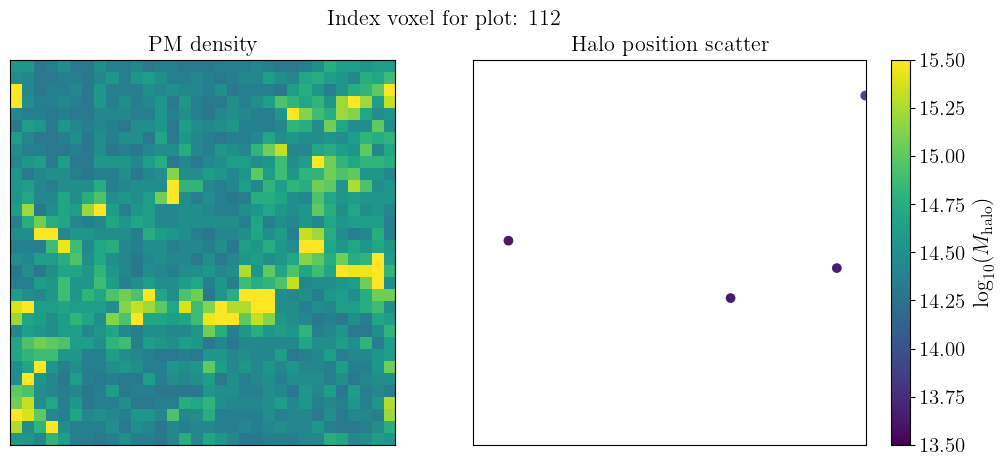

In [ ]:
fig, (ax2, ax3) = pl.subplots(1, 2, figsize=(13, 5))
BoxSize = 1000.
grid = 32
xmin = BoxSize/grid/2
# indp = ind_full[0]
indp = 112
# ax2.imshow(np.sum(delta_box_all_squeezed[indp,:,:,:,0], axis=0).T, origin='lower', vmin=0.0, vmax=0.5)
ax2.imshow(np.sum(delta_vel_box_all_squeezed_all[indp,0,:,:, :], axis=0).T, origin='lower', vmin=-0.1, vmax=0.15)
ax2.set_title('PM density', size=16)
# pl.colorbar()
ax2.set_xticks([])
ax2.set_yticks([])

scatter = ax3.scatter(dfhalo_ngp_wxyzM_reshape_all[indp,:,1][:int(Nhalos_truth_flatten[indp])], dfhalo_ngp_wxyzM_reshape_all[indp,:,2][:int(Nhalos_truth_flatten[indp])], c=dfhalo_ngp_wxyzM_reshape_all[indp,:,-1][:int(Nhalos_truth_flatten[indp])], cmap='viridis', vmin=13.5, vmax=15.5)
ax3.set_xlim(-xmin, xmin)
ax3.set_ylim(-xmin, xmin)
ax3.set_title('Halo position scatter', size=16)
ax3.set_xticks([])
ax3.set_yticks([])

cbar = pl.colorbar(scatter, ax=ax3)
cbar.set_label(r'$\log_{10}(M_{\rm halo})$', size=16)
cbar.ax.tick_params(labelsize=15)

pl.suptitle(f'Index voxel for plot: {indp}', size=16)
pl.subplots_adjust(wspace=0.05)





In [ ]:
vx_all_3D = delta_vel_box_all_squeezed_all[indp,3,:,:, :]

# dfhalo_ngp_wxyzM_reshape_all.shape
xyz_all_true = dfhalo_ngp_wxyzM_reshape_all[:,:,:3].reshape((-1, 3))
vx_all_true = dfhalo_ngp_wxyzM_reshape_all[:,:,3].reshape((-1))

indsel = np.where(vx_all_true != 0)[0]
xyz_all_true = xyz_all_true[indsel]
vx_all_true = vx_all_true[indsel]

grid = 32
xall = (np.linspace(-xmin, xmin, grid + 1))
xarray = 0.5 * (xall[1:] + xall[:-1])
yarray = np.copy(xarray)
zarray = np.copy(xarray)
x_cy, y_cy, z_cy = np.meshgrid(xarray, yarray, zarray, indexing='ij')




In [ ]:
snapnum = 3
mass_type = 'rockstar_200c'
snap_dir_base = '/mnt/home/fvillaescusa/ceph/Quijote/Halos/Rockstar/fiducial_HR'
snapdir = snap_dir_base + '/' + str(isim_fid)  #folder hosting the catalogue
rockstar = np.loadtxt(snapdir + '/out_' + str(snapnum) + '_pid.list')
with open(snapdir + '/out_' + str(snapnum) + '_pid.list', 'r') as f:
    lines = f.readlines()
header = lines[0].split()
# get the properties of the halos
pos_h_truth = rockstar[:,header.index('X'):header.index('Z')+1]
vel_h_truth = rockstar[:,header.index('VX'):header.index('VZ')+1]
if mass_type == 'rockstar_vir':
    index_M = header.index('Mvir')                    
    mass_truth = rockstar[:,index_M]  #Halo masses in Msun/h
if mass_type == 'rockstar_200c':
    index_M = header.index('M200c')                    
    mass_truth = rockstar[:,index_M]  #Halo masses in Msun/h

# Mmin_cut = 1e13
Mmin_cut = 10**13.5
lgMass_truth = np.log10(mass_truth)
indsel = np.where(mass_truth > Mmin_cut)[0]
# print(grid, len(indsel), len(mass_truth), np.amin(lgMass_truth), np.log10(Mmin_cut))
pos_h_truth = pos_h_truth[indsel]
lgMass_truth = lgMass_truth[indsel]
vel_h_truth = vel_h_truth[indsel]



/tmp/ipykernel_76619/142337693.py:21: RuntimeWarning: divide by zero encountered in log10
  lgMass_truth = np.log10(mass_truth)


In [ ]:
from scipy.interpolate import RegularGridInterpolator
vx_all_3D_interp = RegularGridInterpolator((xarray, yarray, zarray), vx_all_3D, bounds_error=False)

vx_eval_interp = vx_all_3D_interp(xyz_all_true)


# np.amin(xyz_all_true), np.amax(xyz_all_true)
pl.figure()
pl.scatter(vx_eval_interp*1000, vx_all_true, s=0.1)



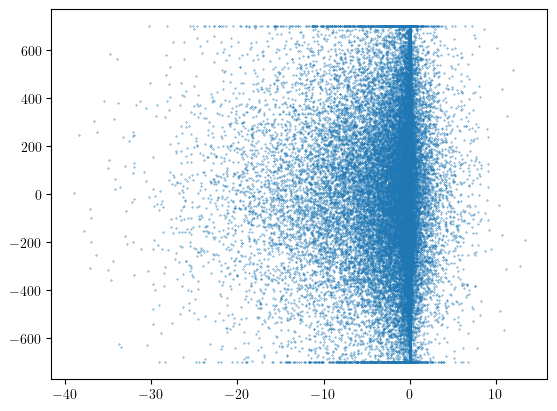

In [ ]:
# np.amin(xarray)


-15.13671875

In [ ]:
vx_all_3D



array([[[ 0.        ,  0.        ,  0.        , ...,  0.        ,
          0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        , ...,  0.        ,
          0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        , ...,  0.        ,
          0.        ,  0.        ],
        ...,
        [ 0.        ,  0.        ,  0.        , ...,  0.        ,
          0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        , ...,  0.        ,
          0.        ,  0.        ],
        [ 0.        , -0.02203961,  0.        , ...,  0.        ,
          0.        ,  0.        ]],

       [[ 0.        ,  0.        ,  0.        , ...,  0.        ,
          0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        , ...,  0.        ,
          0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        , ...,  0.        ,
          0.        ,  0.        ],
        ...,
        [ 0.        ,  0.        ,  0.        , ...,  

In [1]:
import numpy as np
from scipy.special import spence
from scipy.optimize import fmin, differential_evolution, minimize
from scipy.optimize import newton
import scipy as sp
import scipy.interpolate as interpolate
from colossus.cosmology import cosmology
import astropy.units as u
from astropy import constants as const
from colossus.halo import mass_so



pressure_params_def = {
    'P0': {
        'A0': 18.1,
        'alpha_m': 0.154,
        'alpha_z': -0.758
        },
    'xc': {
        'A0': 0.497,
        'alpha_m': -0.00865,
        'alpha_z': 0.731
        },
    'beta': {
        'A0': 4.35,
        'alpha_m': 0.0393,
        'alpha_z': 0.415
        }
    }
density_params_def = {
    'rho0': {
        'A0': 4e3,
        'alpha_m': 0.29,
        'alpha_z': -0.66
        },
    'alpha': {
        'A0': 0.88,
        'alpha_m': -0.03,
        'alpha_z': 0.19
        },
    'beta': {
        'A0': 3.83,
        'alpha_m': 0.04,
        'alpha_z': -0.025
        }
    }


class Battaglia_12_16:

    def __init__(
            self,
            M,
            z,
            cosmo=None,
            pressure_params_def=pressure_params_def,
            density_params_def=density_params_def,
            mdef_Delta=200
        ):
        '''Note that here M is in Msun/h'''
        if cosmo is None:
            cosmo = cosmology.setCosmology('planck18')
        self.cosmo = cosmo
        self.h = cosmo.H0 / 100.
        self.M = M / self.h
        # print('M = ', self.M)
        self.z = z
        self.mdef_Delta = mdef_Delta
        mdef = str(mdef_Delta) + 'c'
        self.pressure_params_def = pressure_params_def
        self.density_params_def = density_params_def
        self.rDelta = mass_so.M_to_R(M, z, mdef) / (1000. * self.h)
        self.rho0_density = self.get_params('rho0', density_params_def)
        self.alpha_density = self.get_params('alpha', density_params_def)
        self.beta_density = self.get_params('beta', density_params_def)
        self.xc_density = 0.5
        self.gamma_density = -0.2

        self.P0_pressure = self.get_params('P0', pressure_params_def)
        self.xc_pressure = self.get_params('xc', pressure_params_def)
        self.beta_pressure = self.get_params('beta', pressure_params_def)
        self.alpha_pressure = 1.0
        self.gamma_pressure = -0.3

        # self.rho_crit_z = cosmo.rho_crit(z) * 1e9 * h**2
        self.rho_crit_z = cosmo.rho_c(z) * 1e9 * self.h**2
        # self.rho_crit_z = cosmo.rho_c(z) * 1e9      
        self.fb = cosmo.Ob0 / cosmo.Om0

    def get_params(self, key, params_dict):
        A0 = params_dict[key]['A0']
        alpha_m = params_dict[key]['alpha_m']
        alpha_z = params_dict[key]['alpha_z']
        A = A0 * (self.M / 1e14)**alpha_m * (1 + self.z)**alpha_z
        return A

    def get_rho_fit(self, r):
        x = r / (self.rDelta * self.h)
        rho_fit = self.rho0_density * ((x / self.xc_density)**self.gamma_density) * (
            1 + (x / self.xc_density)**self.alpha_density
            )**(-(self.beta_density - self.gamma_density) / self.alpha_density)
        return rho_fit

    def get_P_fit(self, r):
        x = r / (self.rDelta * self.h)
        P_fit = self.P0_pressure * (x / self.xc_pressure
                          )**self.gamma_pressure * (1 +
                                                    (x / self.xc_pressure)**self.alpha_pressure)**(-self.beta_pressure)
        return P_fit

    def get_rho_gas(self, r):
        rho_fit = self.get_rho_fit(r)
        return self.rho_crit_z * rho_fit

    def get_Pth(self, r):
        P_fit = self.get_P_fit(r)
        coeff = (const.G * (const.M_sun**2) / ((1.0 * u.Mpc)**4)).to((u.keV / (u.cm**3))).value

        P_Delta = coeff * self.M * self.mdef_Delta * self.rho_crit_z * self.fb / (2. * self.rDelta)

        return P_Delta * P_fit


        

In [2]:
BP_obj = Battaglia_12_16(1e14, 0.0)


In [3]:
r_array = np.logspace(0.1, 1.5, 20)
Pth_array = BP_obj.get_Pth(r_array)


In [4]:
import matplotlib.pyplot as pl
%matplotlib inline


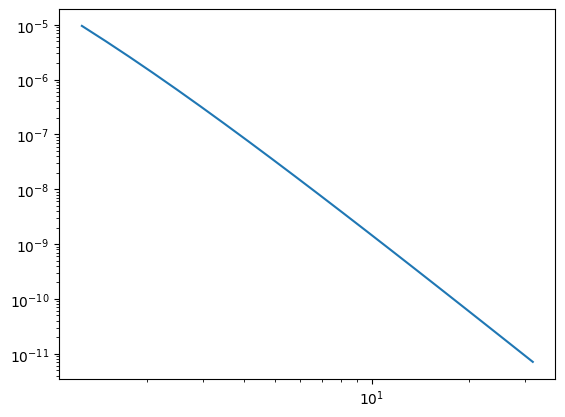

In [5]:
pl.figure()
pl.plot(r_array, Pth_array)
pl.xscale('log')
pl.yscale('log')
